<KeysViewHDF5 ['u']>
(78000, 64)
(19500, 64)
(14500,)
<KeysViewHDF5 ['u']>
(78000, 64)
(19500, 64)
(14500,)
<KeysViewHDF5 ['u']>
(78000, 64)
(19500, 64)
(14500,)
<KeysViewHDF5 ['u']>
(78000, 64)
(19500, 64)
(14500,)
<KeysViewHDF5 ['u']>
(78000, 64)
(19500, 64)
(14500,)
<KeysViewHDF5 ['u']>
(78000, 64)
(19500, 64)
(14500,)


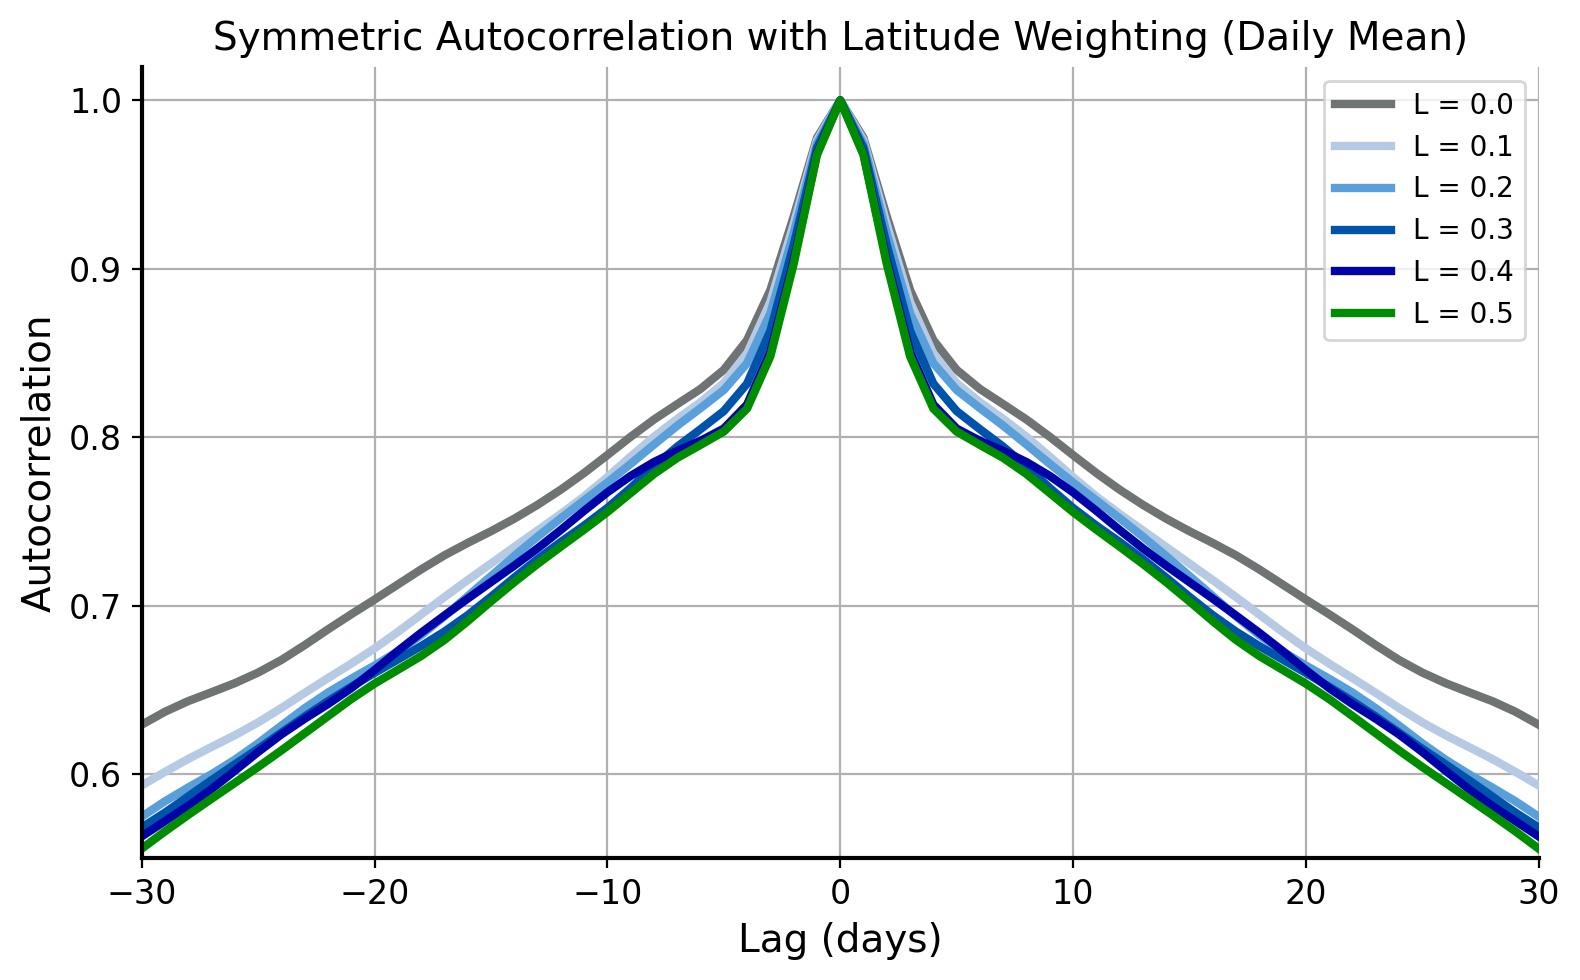

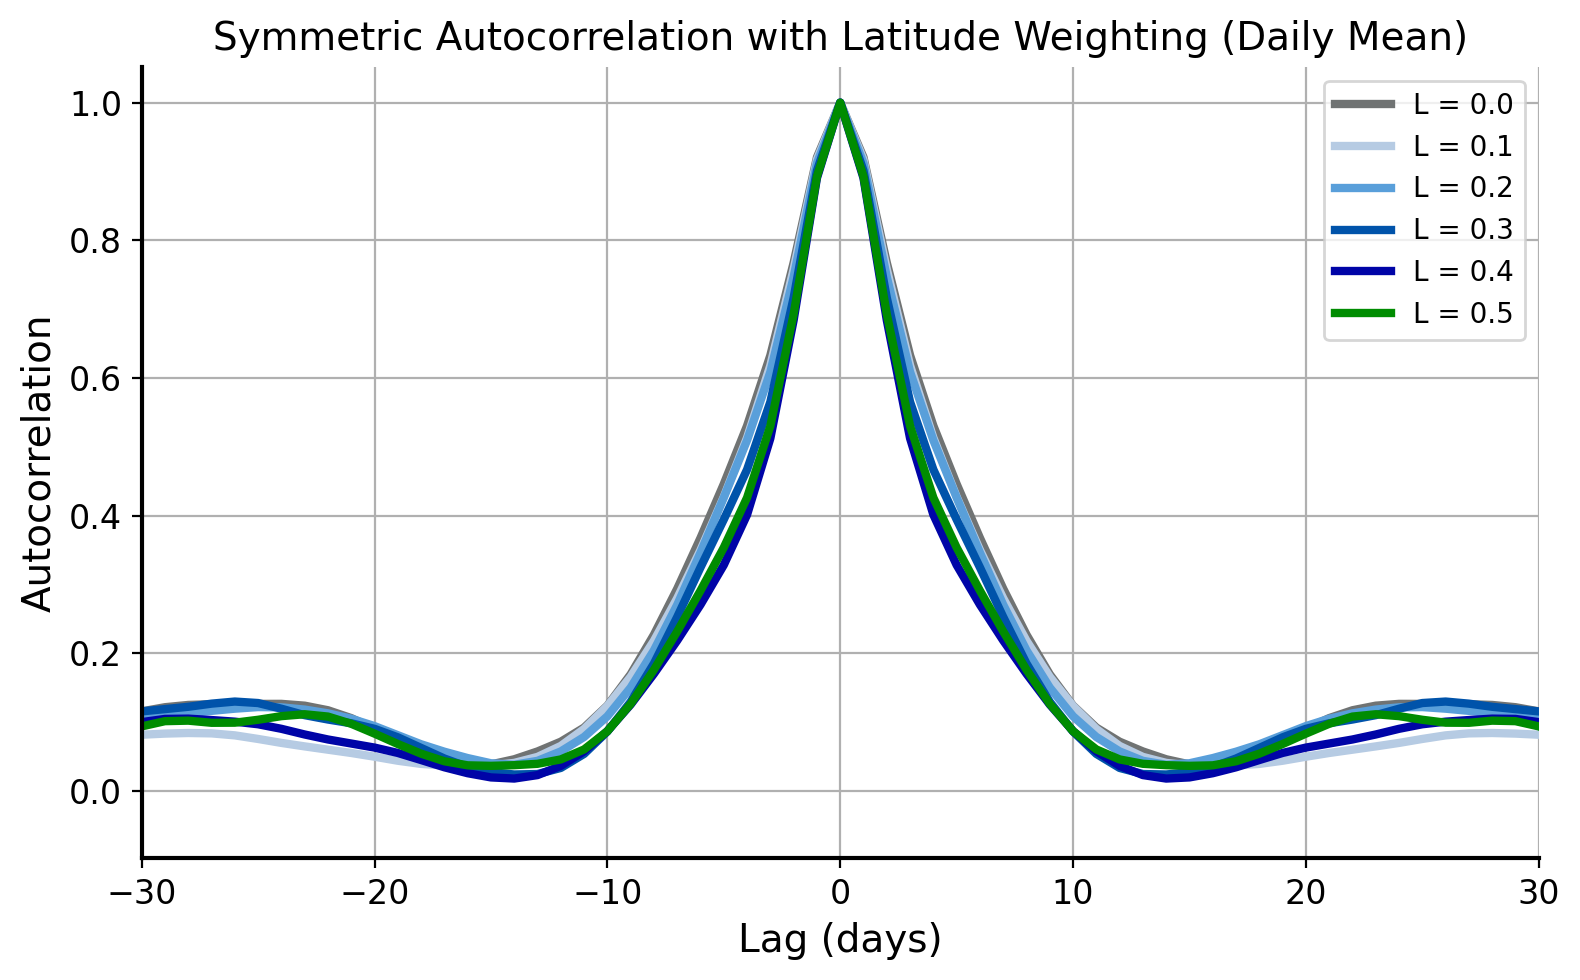

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

sys.path.append("back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
from EOF import EOF


class Moist_Dycore_Package:
    def __init__(self, zonal_dimension: int = 3):
        self.zonal_dimension = zonal_dimension

    def zonal_mean(self, data):
        return np.mean(data, axis=self.zonal_dimension, keepdims=True)

    def zonal_anomaly(self, data):
        mean = self.zonal_mean(data)
        np.subtract(data, mean, out=data)
        return data

    def load_data(self, file_path, variable_name):
        with h5py.File(file_path, "r") as file:
            print(file.keys())
            return np.array(file[variable_name], dtype=np.float32)

    def calculate_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        daily_mean = data[:num_days * 4].reshape(num_days, 4, -1).mean(axis=1)
        return daily_mean

    def calculate_3d_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        Input: (Time, Z, Y) -> Output: (Days, Z, Y)
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        
        # We reshape to (Days, 4_steps, Z, Y)
        # data.shape[1] is Z, data.shape[2] is Y
        reshaped_data = data[:num_days * 4].reshape(num_days, 4, data.shape[1], data.shape[2])
        
        # Calculate mean across the 4-step axis (axis 1)
        daily_mean = reshaped_data.mean(axis=1)
        
        return daily_mean

    def calculate_EOF_with_custom_class(self, input_data, latitudes, n_components: int = 32, field: str = "2D"):
        weights = np.sqrt(np.cos(np.radians(latitudes)))
        weighted_data = input_data * weights

        eof_instance = EOF((weighted_data,), n_components=n_components, field=field)
        eof_instance.get()

        EOF_modes = eof_instance.EOF[:2]
        PCs = eof_instance.PC[0]
        PC2 = eof_instance.PC[1]
        
        explained_variance = eof_instance.explained

        PCs_normalized = PCs / PCs.std(axis=0)
        PC2_normalized = PC2 / PC2.std(axis=0)
        

        return EOF_modes, PCs_normalized, PC2_normalized, explained_variance

    def symmetric_autocorr(self, x, max_lag, split_to_chunk, window_length, overlap=250):
        if not split_to_chunk:
            corr = np.zeros(2 * max_lag + 1)
            for l in range(-max_lag, max_lag + 1):
                if l == 0:
                    corr[l + max_lag] = 1.0
                elif l > 0:
                    corr[l + max_lag] = np.corrcoef(x[l:], x[:-l])[0][1]
                else:
                    corr[l + max_lag] = np.corrcoef(x[:l], x[-l:])[0][1]
            return corr
        else:
            step_size = window_length - overlap
            num_windows = (len(x) - overlap) // step_size
            corr = np.zeros((num_windows, 2 * max_lag + 1))

            for i in range(num_windows):
                start = i * step_size
                end = start + window_length
                x_window = x[start:end]

                if len(x_window) < window_length:
                    break

                for l in range(-max_lag, max_lag + 1):
                    if l == 0:
                        corr[i, l + max_lag] = 1.0
                    elif l > 0:
                        corr[i, l + max_lag] = np.corrcoef(x_window[l:], x_window[:-l])[0, 1]
                    else:
                        corr[i, l + max_lag] = np.corrcoef(x_window[:l], x_window[-l:])[0, 1]

            return corr.mean(axis=0)


# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
PR_values = [0, 10, 20, 30, 40, 50]
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0
auto_length = 100
window_length = 500
split_to_chunk = False
latitudes = np.linspace(0, 90, 32)

# Load data, calculate daily mean, and compute PC1 for all PR values
PC1_all  = []
PC2_all  = []

EOFs_all = []


for PR in PR_values:
    file_path = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    variable_name = "u"    
    u_data = moist_dycore.load_data(file_path, variable_name)


    print(u_data.shape)
    # Calculate daily mean
    u_daily = moist_dycore.calculate_daily_mean(u_data)
    # u_daily = moist_dycore.calculate_3d_daily_mean(u_data)
    
    print(u_daily.shape)
    # Use the custom EOF class
    EOFs, PC_normalized, PC2_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(u_daily[5000:, 32:], latitudes, n_components=32, field="1D")
    # EOFs, PC_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(u_daily[5000:, :, 32:], latitudes, n_components=32, field="2D")
    EOFs_all.append(EOFs[:])  # Extract normalized PC1 for the current PR value
    PC1_all.append(PC_normalized[:])  # Extract normalized PC1 for the current PR value
    PC2_all.append(PC2_normalized[:])  # Extract normalized PC2 for the current PR value
        
    
    print(PC_normalized[:].shape)
    
    

PC1_all  = np.array(PC1_all)
PC2_all  = np.array(PC2_all)

EOFs_all = np.array(EOFs_all)


# Calculate symmetric autocorrelation for PC1
autocorr_results = []
for i in range(len(PR_values)):
    autocorr_results.append(
        moist_dycore.symmetric_autocorr(PC1_all[i, :], auto_length, split_to_chunk, window_length)
    )

# PC2
autocorr2_results = []
for i in range(len(PR_values)):
    autocorr2_results.append(
        moist_dycore.symmetric_autocorr(PC2_all[i, :], auto_length, split_to_chunk, window_length)
    )
    

# tau for plotting
tau_full = np.arange(-auto_length, auto_length + 1)

# Plot the symmetric autocorrelation
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for i, PR in enumerate(PR_values):
    ax.plot(tau_full, autocorr_results[i], label=f"L = {PR * 0.01}", color=colors[i], lw=3)

# Customize plot
ax.set_title("Symmetric Autocorrelation with Latitude Weighting (Daily Mean)", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.ylim([0.55, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#################################################################################################
# Plot the symmetric autocorrelation
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for i, PR in enumerate(PR_values):
    ax.plot(tau_full, autocorr2_results[i], label=f"L = {PR * 0.01}", color=colors[i], lw=3)

# Customize plot
ax.set_title("Symmetric Autocorrelation with Latitude Weighting (Daily Mean)", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
# plt.ylim([0.55, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Processing: L = 0.0
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.1
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.2
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.3
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.4
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.5
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: Midlat
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: Trop
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: 

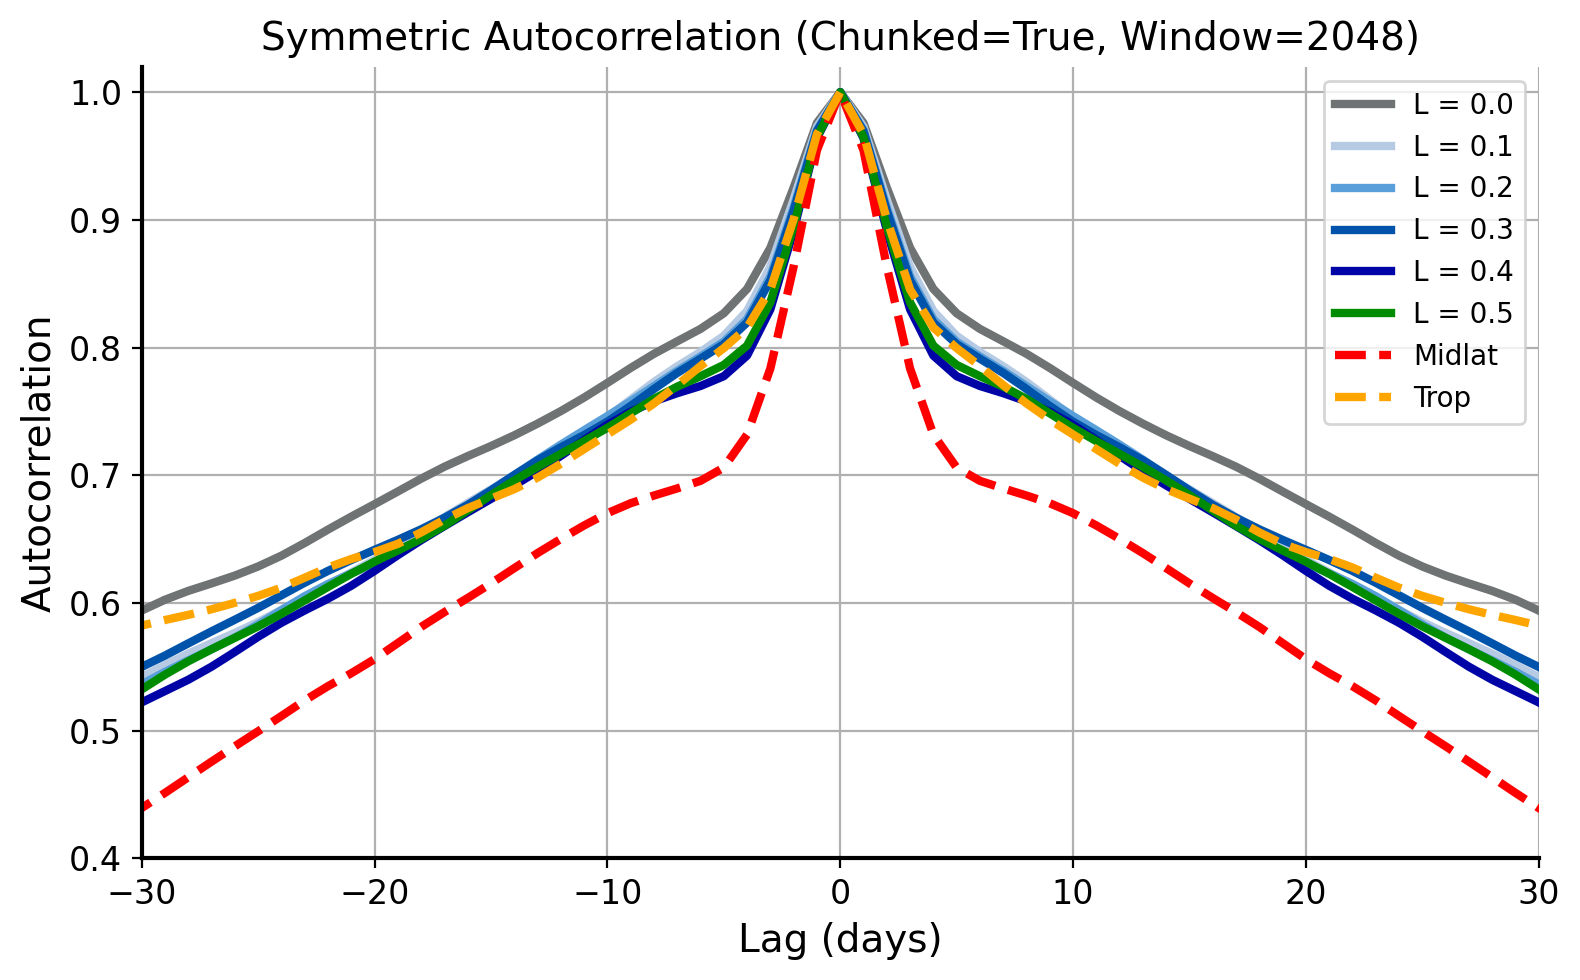

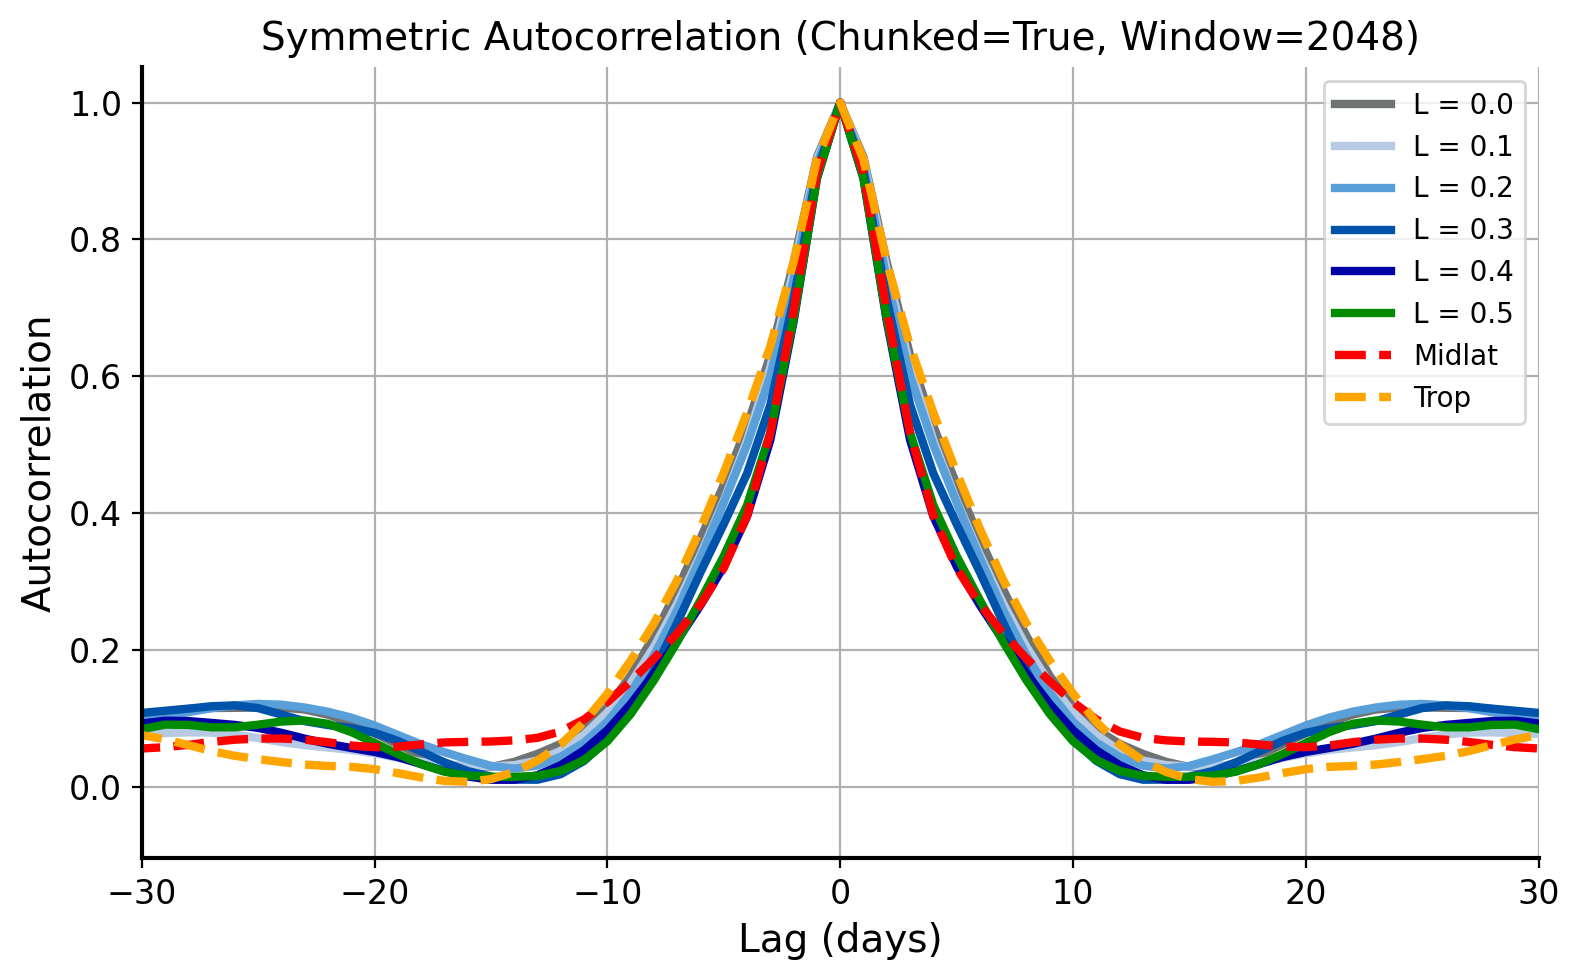

In [3]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

# --- Main Script ---

# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
auto_length = 100
window_length = 2048
split_to_chunk = True
latitudes = np.linspace(0, 90, 32)
variable_name = "u"

# 1. Configuration: Define all experiments
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01}",
        "color": col,
        "linestyle": "-", 
        "path": f"/data92/PeterChang/1120_preprocessing/PR{val}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    })

# B. Midlat experiment
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "path": "/data92/PeterChang/Moist_Dycore_only_midlatitude_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# C. Trop experiment
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--", 
    "path": "/data92/PeterChang2/Moist_Dycore_only_tropical_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# 2. Data Processing Loop
PC1_results = []
PC2_results = []
# PC1_all_normalized = np.zeros((8,14500))
# PC2_all_normalized = np.zeros((8,14500))



valid_experiments_indices = []

for i, exp in enumerate(experiments):
    print(f"Processing: {exp['label']}")
    
    # Load Data
    u_data = moist_dycore.load_data(exp["path"], variable_name)
    
    if u_data is None:
        continue

    print(f"  Data shape: {u_data.shape}")

    # Calculate daily mean
    u_daily = moist_dycore.calculate_daily_mean(u_data)
    print(f"  Daily mean shape: {u_daily.shape}")
    
    # Calculate EOF
    # Slicing assumes [Time, Lat] or [Time, ... Lat ...] where 32: selects the desired hemisphere
    try:
        data_for_eof = u_daily[5000:, 32:]
        
        # Check if dimensions match latitudes array
        if data_for_eof.shape[1] != len(latitudes):
            print(f"  Warning: Data latitude dim ({data_for_eof.shape[1]}) does not match latitudes array ({len(latitudes)})")

        EOFs, PC_normalized, PC2_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(
            data_for_eof, 
            latitudes, 
            n_components=32, 
            field="1D"
        )
        
        # Assuming PC_normalized is shape (Time, Modes), select PC1 (index 0)
        # If your EOF package returns (Time, Modes), we take all times for mode 0
        if PC_normalized.ndim > 1:
             pc1_series = PC_normalized[:, 0]
             pc2_series = PC2_normalized[:,0]
            
        else:
             pc1_series = PC_normalized # Fallback if it returns 1D
             pc2_series = PC2_normalized # Fallback if it returns 1D
            
        
        PC1_results.append(pc1_series)
        PC2_results.append(pc2_series)
        
        valid_experiments_indices.append(i)
        print(f"  PC1 extracted, length: {pc1_series.shape[0]}\n")
        
    except Exception as e:
        print(f"  Error in EOF calculation for {exp['label']}: {e}\n")

# 3. Calculate Autocorrelation & Plot
autocorr_results = []
autocorr2_results = []


print("Calculating Autocorrelation...")
for pc_data in PC1_results:
    autocorr = moist_dycore.symmetric_autocorr(
        pc_data, 
        max_lag=auto_length, 
        split_to_chunk=split_to_chunk, 
        window_length=window_length,
        overlap=int(window_length/2) # Ensure this matches your desired overlap
    )
    autocorr_results.append(autocorr)

for pc_data in PC2_results:
    autocorr2 = moist_dycore.symmetric_autocorr(
        pc_data, 
        max_lag=auto_length, 
        split_to_chunk=split_to_chunk, 
        window_length=window_length,
        overlap=int(window_length/2) # Ensure this matches your desired overlap
    )
    autocorr2_results.append(autocorr2)

# Tau for plotting
tau_full = np.arange(-auto_length, auto_length + 1)

# Plotting
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for idx, exp_idx in enumerate(valid_experiments_indices):
    exp_config = experiments[exp_idx]
    ax.plot(tau_full, autocorr_results[idx], 
            label=exp_config["label"], 
            color=exp_config["color"], 
            linestyle=exp_config["linestyle"],
            lw=3)

# Customize plot
ax.set_title(f"Symmetric Autocorrelation (Chunked={split_to_chunk}, Window={window_length})", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.ylim([0.4, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
#############################################################################################################
# Plotting
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for idx, exp_idx in enumerate(valid_experiments_indices):
    exp_config = experiments[exp_idx]
    ax.plot(tau_full, autocorr2_results[idx], 
            label=exp_config["label"], 
            color=exp_config["color"], 
            linestyle=exp_config["linestyle"],
            lw=3)

# Customize plot
ax.set_title(f"Symmetric Autocorrelation (Chunked={split_to_chunk}, Window={window_length})", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
# plt.ylim([0.4, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

(14500,)

In [18]:
PC2_results[0]

(14500,)

In [4]:
import numpy as np
import h5py

# --- 1. Configuration: Define all experiments (PR + Midlat + Trop) ---
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01:.1f}",
        "color": col,
        "linestyle": "-",  
        "marker": "o",
        "L_val": val * 0.01,
        # Path for U variable
        "path_u": f"/data92/PeterChang/1120_preprocessing/PR{val}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    })

# B. Midlat experiment (Red, Dotted)
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang/Moist_Dycore_only_midlatitude_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# C. Trop experiment (Orange, Dotted)
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang2/Moist_Dycore_only_tropical_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

num_exp = len(experiments)

# --- 2. Data Calculation Loop ---

start_day = 500 + 5000
end_day   = 20000
day_length = len(np.arange(start_day, end_day))

print(f"start_day = {start_day}, end_day = {end_day}, total day = {day_length}")
print(f"Total Experiments: {num_exp}")

# Initialize arrays
Uzm_all = np.zeros((num_exp, day_length, 64))
EMF = np.zeros((num_exp, day_length, 64))

# Loop through all experiments
for i, exp in enumerate(experiments):
    path_u = exp["path_u"]
    # Derive EMF path from U path by replacing folder/filenames
    path_emf = path_u.replace("u_add_time_dim", "EMF_add_time_dim")\
                     .replace("u_climatology", "EMF_climatology")\
                     .replace("/u/", "/EMF/") # Just in case directory structure varies slightly
    
    print(f"Processing {exp['label']}...")
    
    # 1. Load U
    try:
        with h5py.File(path_u, 'r') as f:
            # Slicing logic from your code
            # data shape expected: (Time, Y) or (Time, Z, Y)? 
            # Your snippet used: f["u"][...].reshape(...,4,64).mean(axis=1)
            # This implies raw data is 4x daily resolution.
            
            raw_u = f["u"][int(start_day-500)*4:, :]
            # Reshape to (Days, 4, Lat) and mean over daily cycle
            limit = min(day_length * 4, raw_u.shape[0])
            # Ensure we don't go out of bounds if file is shorter
            valid_days = limit // 4
            
            Uzm_all[i, :valid_days, :] = raw_u[:valid_days*4, :].reshape(valid_days, 4, 64).mean(axis=1)
    except Exception as e:
        print(f"  Error loading U for {exp['label']}: {e}")

    # 2. Load EMF
    try:
        with h5py.File(path_emf, 'r') as f:
            raw_emf = f["EMF"][int(start_day-500)*4:, :]
            limit = min(day_length * 4, raw_emf.shape[0])
            valid_days = limit // 4
            EMF[i, :valid_days, :] = raw_emf[:valid_days*4, :].reshape(valid_days, 4, 64).mean(axis=1)
    except Exception as e:
        print(f"  Error loading EMF for {exp['label']}: {e}\n  (Path tried: {path_emf})")


# --- 3. Calculate dmdy ---
radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy ** 2

dmdy = np.zeros((num_exp, day_length, 64))

for a in range(num_exp):
    Mzm = EMF[a]
    
    # Central difference for interior points
    for k in range(1, 64-1):
        dmdy[a,:,k] = -(Mzm[:,k+1] * (cy[k]**2) - Mzm[:,k-1]* (cy[k]**2)) / \
                       (radius * (cy[k]**2) * (yd[k+1] - yd[k-1]))
    
    # Boundary conditions
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))

print(f"dmdy calculation complete. Shape: {dmdy.shape}")

start_day = 5500, end_day = 20000, total day = 14500
Total Experiments: 8
Processing L = 0.0...
Processing L = 0.1...
Processing L = 0.2...
Processing L = 0.3...
Processing L = 0.4...
Processing L = 0.5...
Processing Midlat...
Processing Trop...
dmdy calculation complete. Shape: (8, 14500, 64)


In [5]:
# --- 4. Renew PP_all_u and m_fig3 for ALL 8 experiments ---
num_lat = 32
m_fig3_results = np.zeros((8,14500))
m2_fig3_results = np.zeros((8,14500))


# Update array dimensions to match the new number of experiments (8)
num_exp_updated = len(experiments)

# Re-initialize arrays with the correct shape
PP_all_u = np.zeros((num_exp_updated, day_length))
PP2_all_u = np.zeros((num_exp_updated, day_length))

m_fig3 = np.zeros((num_exp_updated, day_length))
m2_fig3 = np.zeros((num_exp_updated, day_length))


print(f"Re-calculating EOF and projections for {num_exp_updated} experiments...")

# Re-run the generation of m_fig3 and PP_all_u using the updated data
for exp_idx in range(num_exp_updated):
    # Apply cosine latitude weighting
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    
    # Compute EOF (assuming your custom EOF class/function is already imported/defined)
    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    # Store Principal Component and EOF pattern
    PP_all_u[exp_idx]  = single_EOF_u.PC[0]
    PP2_all_u[exp_idx] = single_EOF_u.PC[1]
    
    EOF_u_final  = single_EOF_u.EOF[0]
    EOF2_u_final = single_EOF_u.EOF[1]
    
    
    # Project dmdy onto the EOF to get the m(t) forcing time series
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)
    m2_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF2_u_final)

    m_fig3_results[exp_idx]  = m_fig3[exp_idx]  / m_fig3[exp_idx].std()
    m2_fig3_results[exp_idx] = m2_fig3[exp_idx] / m2_fig3[exp_idx].std()
    

print(f"Successfully updated m_fig3! New shape: {m_fig3.shape}")

# Now you can safely proceed to your Welch's method spectral analysis block!

Re-calculating EOF and projections for 8 experiments...
Successfully updated m_fig3! New shape: (8, 14500)


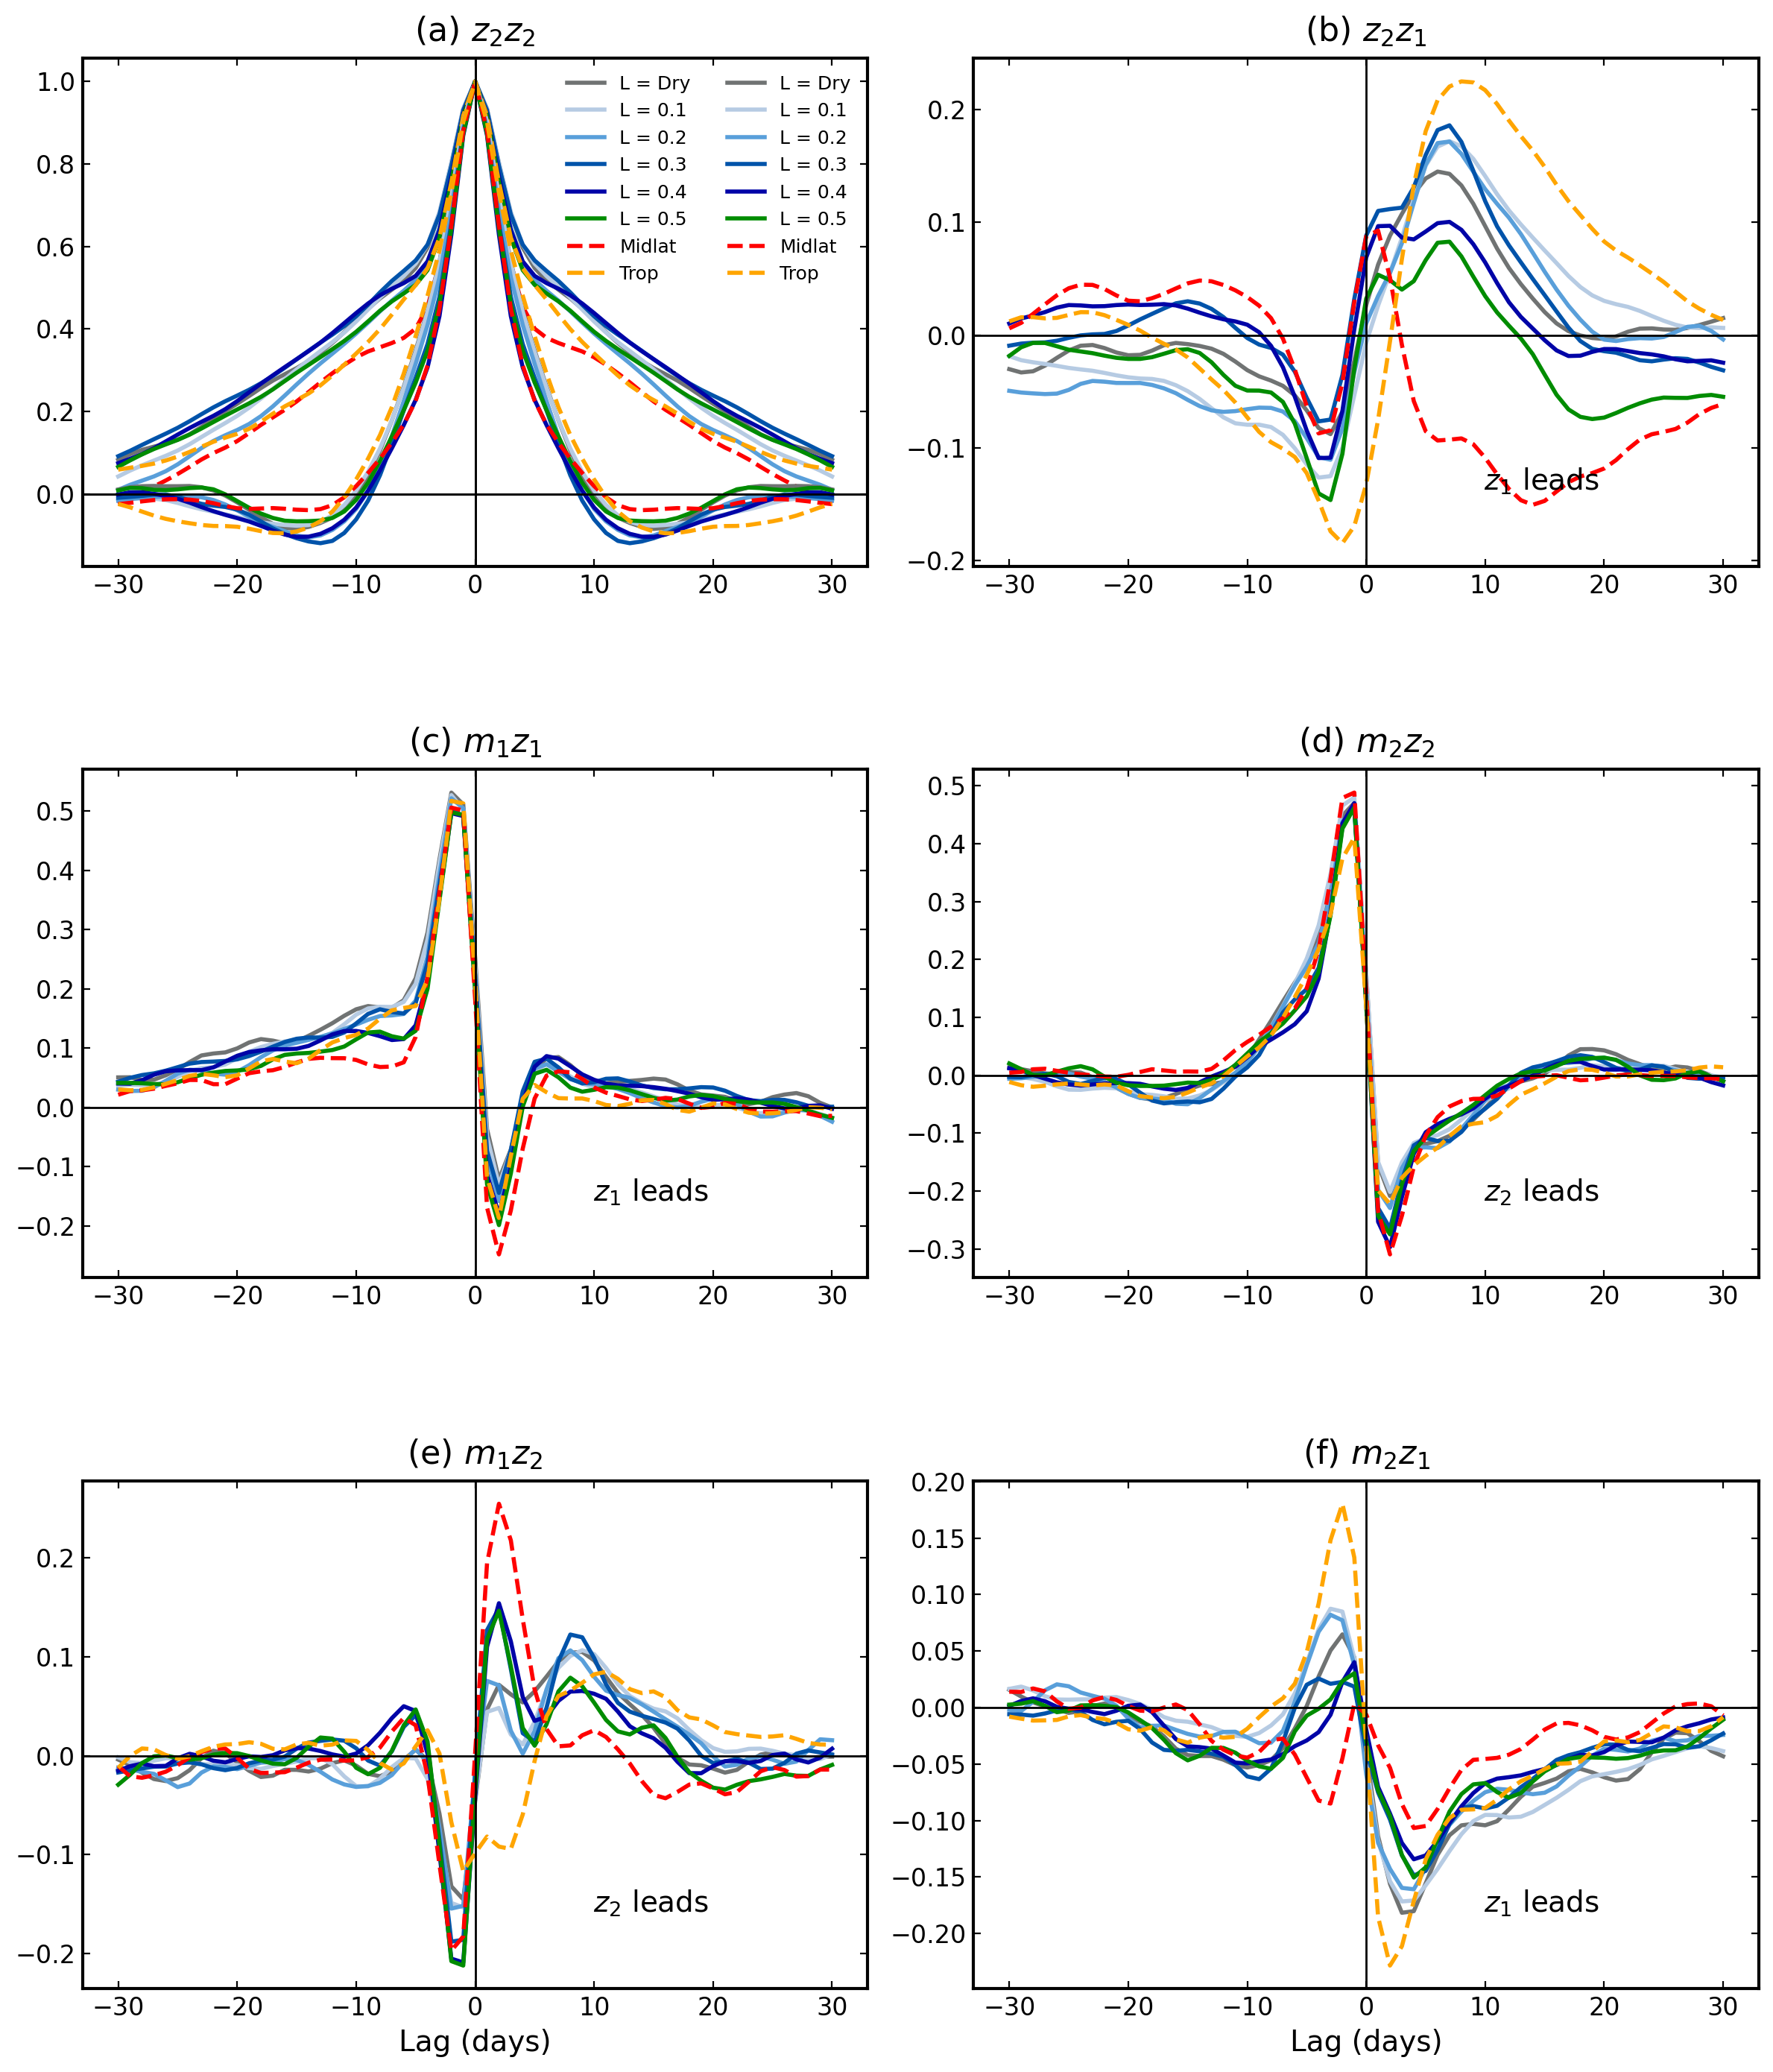

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Assumed Setup Variables
auto_length  = 30
chunk_size   = 256 
overlap_size = 0 
mpl.rcParams['axes.linewidth'] = 1.5

# --- 1. Helper Function to Plot a Single Panel ---
def plot_panel(ax, var_y, var_x, title, lead_text=None, show_legend=False):
    """Calculates cross-correlation and plots it on the given axes."""
    
    for idx, exp in enumerate(experiments):
        # Safety check
        if idx >= len(var_y) or idx >= len(var_x): continue
        
        # Calculate cross-correlation
        lags, cross_corr_values = cross_corr_chunked(
            var_y[idx], 
            var_x[idx], 
            auto_length, 
            chunk_size, 
            overlap_size
        )
        
        label = "L = Dry" if exp["label"] == "L = 0.0" else exp["label"]
        
        # Plot the line
        ax.plot(lags, cross_corr_values, label=label, 
                color=exp["color"], linestyle=exp["linestyle"], lw=2)

    # Panel Formatting
    ax.set_title(title, fontsize=16, pad=8)
    ax.axhline(0, color='black', lw=1) # Horizontal zero line
    ax.axvline(0, color='black', lw=1) # Vertical zero line
    
    # Add the "z1 leads" / "z2 leads" text if provided
    if lead_text:
        ax.text(0.65, 0.15, lead_text, transform=ax.transAxes, fontsize=14)

    # Ticks and Labels
    ax.set_xticks(np.arange(-30, 31, 10))
    ax.tick_params(axis="both", labelsize=12, direction="in", right=True, top=True)
    
    # Only add the legend to the panel we specify
    if show_legend:
        ax.legend(loc="upper right", prop={"size": 9}, frameon=False, ncols=2)


# --- 2. Main Execution Block (6-Panel Figure) ---

# Create a 3-row, 2-column figure
fig, axes = plt.subplots(3, 2, figsize=(12, 14), dpi=200)

# Panel (a): z1z1 (Auto-correlation of PC1)
plot_panel(axes[0, 0], PC1_results, PC1_results, 
           title="(a) $z_1z_1$", show_legend=True)

plot_panel(axes[0, 0], PC2_results, PC2_results, 
           title="(a) $z_2z_2$", show_legend=True)

# Panel (b): z2z1 (PC2 and PC1)
plot_panel(axes[0, 1], PC1_results, PC2_results, 
           title="(b) $z_2z_1$", lead_text="$z_1$ leads")

# Panel (c): m1z1 (m1 and PC1)
plot_panel(axes[1, 0], PC1_results, m_fig3_results, 
           title="(c) $m_1z_1$", lead_text="$z_1$ leads")

# Panel (d): m2z2 (m2 and PC2)
plot_panel(axes[1, 1], PC2_results,m2_fig3_results, 
           title="(d) $m_2z_2$", lead_text="$z_2$ leads")

# Panel (e): m1z2 (m1 and PC2)
plot_panel(axes[2, 0], m_fig3_results, PC2_results, 
           title="(e) $m_1z_2$", lead_text="$z_2$ leads")

# Panel (f): m2z1 (m2 and PC1)
plot_panel(axes[2, 1], m2_fig3_results, PC1_results, 
           title="(f) $m_2z_1$", lead_text="$z_1$ leads")

# --- 3. Final Figure Polish ---

# Add global x and y labels manually for a cleaner look
for ax in axes[-1, :]: # Bottom row
    ax.set_xlabel("Lag (days)", fontsize=14)

# Tight layout prevents subplots from overlapping
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # Add a little vertical space between rows
plt.show()

In [9]:
import numpy as np
import h5py

# --- 1. Configuration: Define all experiments (PR + Midlat + Trop) ---
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01:.1f}",
        "color": col,
        "linestyle": "-",  
        "marker": "o",
        "L_val": val * 0.01,
        # Path for U variable
        "path_u": f"/data92/PeterChang/1120_preprocessing/PR{val}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    })

# B. Midlat experiment (Red, Dotted)
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang/Moist_Dycore_only_midlatitude_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# C. Trop experiment (Orange, Dotted)
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang2/Moist_Dycore_only_tropical_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

num_exp = len(experiments)

# --- 2. Data Calculation Loop ---

start_day = 500 + 5000
end_day   = 20000
day_length = len(np.arange(start_day, end_day))

print(f"start_day = {start_day}, end_day = {end_day}, total day = {day_length}")
print(f"Total Experiments: {num_exp}")

# Initialize arrays
Uzm_all = np.zeros((num_exp, day_length, 64))
EMF = np.zeros((num_exp, day_length, 64))

# Loop through all experiments
for i, exp in enumerate(experiments):
    path_u = exp["path_u"]
    # Derive EMF path from U path by replacing folder/filenames
    path_emf = path_u.replace("u_add_time_dim", "EMF_add_time_dim")\
                     .replace("u_climatology", "EMF_climatology")\
                     .replace("/u/", "/EMF/") # Just in case directory structure varies slightly
    
    print(f"Processing {exp['label']}...")
    
    # 1. Load U
    try:
        with h5py.File(path_u, 'r') as f:
            # Slicing logic from your code
            # data shape expected: (Time, Y) or (Time, Z, Y)? 
            # Your snippet used: f["u"][...].reshape(...,4,64).mean(axis=1)
            # This implies raw data is 4x daily resolution.
            
            raw_u = f["u"][int(start_day-500)*4:, :]
            # Reshape to (Days, 4, Lat) and mean over daily cycle
            limit = min(day_length * 4, raw_u.shape[0])
            # Ensure we don't go out of bounds if file is shorter
            valid_days = limit // 4
            
            Uzm_all[i, :valid_days, :] = raw_u[:valid_days*4, :].reshape(valid_days, 4, 64).mean(axis=1)
    except Exception as e:
        print(f"  Error loading U for {exp['label']}: {e}")

    # 2. Load EMF
    try:
        with h5py.File(path_emf, 'r') as f:
            raw_emf = f["EMF"][int(start_day-500)*4:, :]
            limit = min(day_length * 4, raw_emf.shape[0])
            valid_days = limit // 4
            EMF[i, :valid_days, :] = raw_emf[:valid_days*4, :].reshape(valid_days, 4, 64).mean(axis=1)
    except Exception as e:
        print(f"  Error loading EMF for {exp['label']}: {e}\n  (Path tried: {path_emf})")


# --- 3. Calculate dmdy ---
radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy ** 2

dmdy = np.zeros((num_exp, day_length, 64))

for a in range(num_exp):
    Mzm = EMF[a]
    
    # Central difference for interior points
    for k in range(1, 64-1):
        dmdy[a,:,k] = -(Mzm[:,k+1] * (cy[k]**2) - Mzm[:,k-1]* (cy[k]**2)) / \
                       (radius * (cy[k]**2) * (yd[k+1] - yd[k-1]))
    
    # Boundary conditions
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))

print(f"dmdy calculation complete. Shape: {dmdy.shape}")

start_day = 5500, end_day = 20000, total day = 14500
Total Experiments: 8
Processing L = 0.0...
Processing L = 0.1...
Processing L = 0.2...
Processing L = 0.3...
Processing L = 0.4...
Processing L = 0.5...
Processing Midlat...
Processing Trop...
dmdy calculation complete. Shape: (8, 14500, 64)


L = 0.0 tau_z^2: 113.57256
L = 0.1 tau_z^2: 110.32723
L = 0.2 tau_z^2: 114.25765
L = 0.3 tau_z^2: 119.35275
L = 0.4 tau_z^2: 126.30751
L = 0.5 tau_z^2: 130.80621
Midlat tau_z^2: 107.70893
Trop tau_z^2: 130.27789


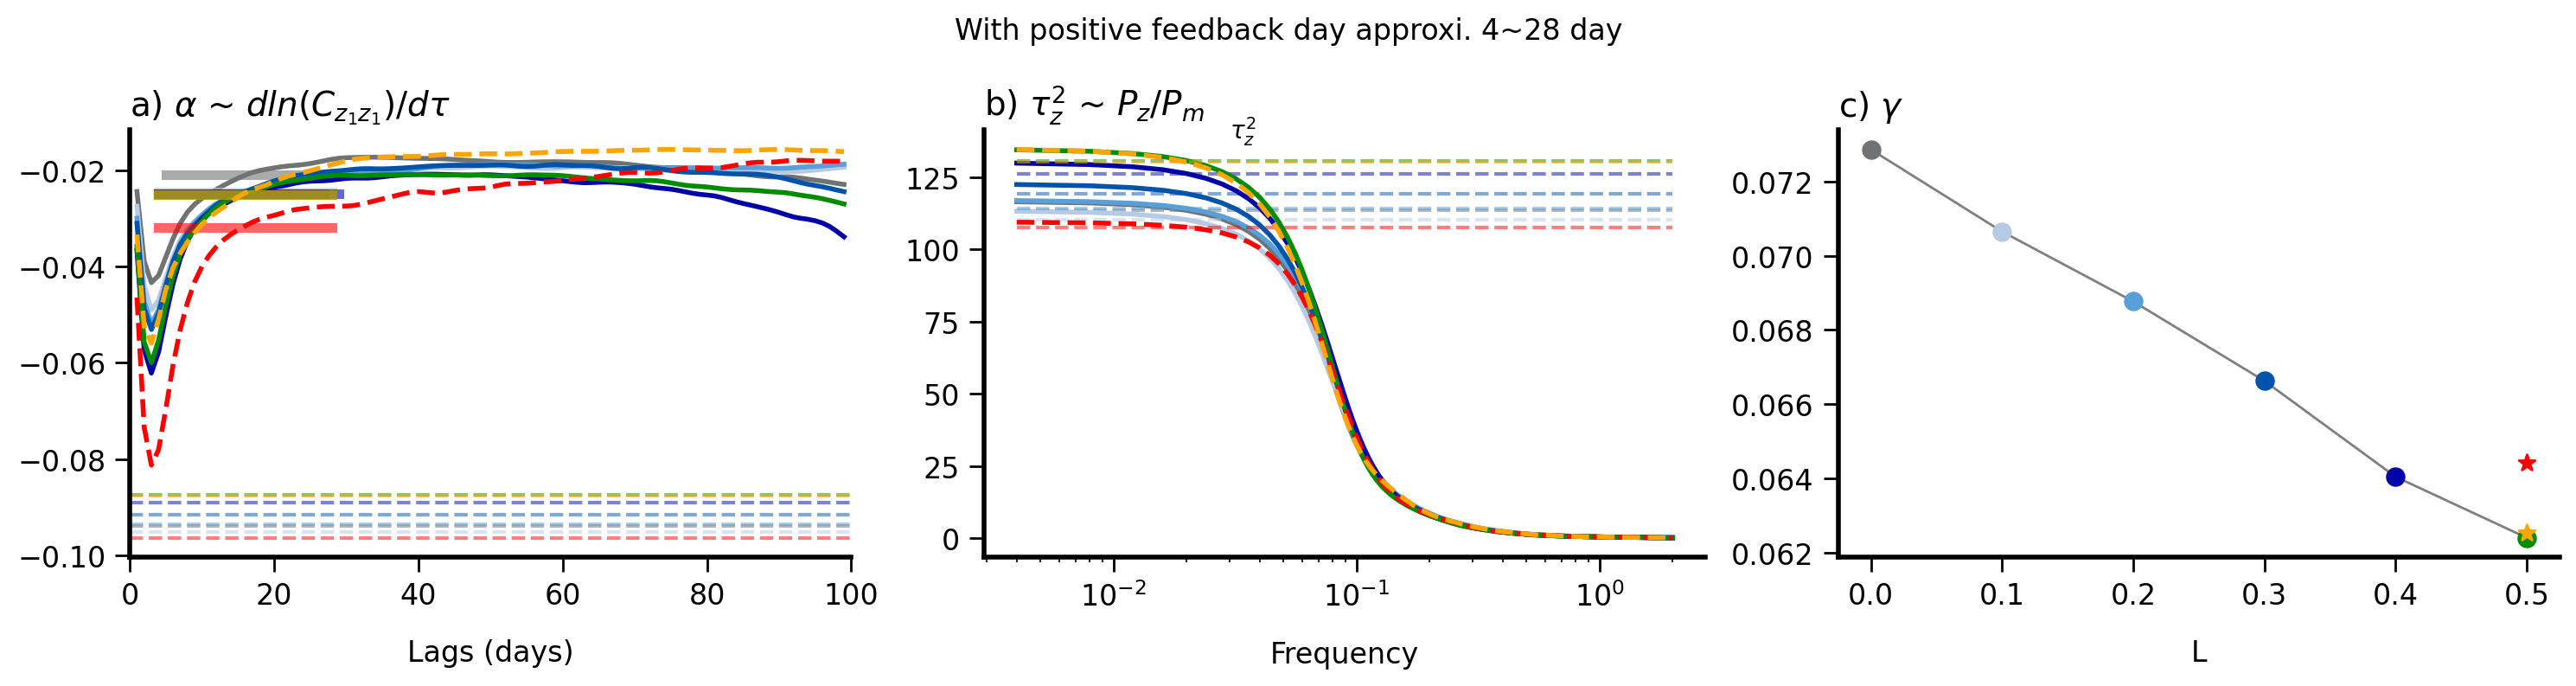

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from EOF import EOF 

# --- Parameters ---
num_lat = 32
lg = 1000 #2048         # Window length
overlap = 500 #1024    # Overlap
num_exp = 8       # Total experiments
day_length = 14500 

# --- Define Specific Windows for Each Experiment ---
# Format: "Label": (start_day, end_day)
forcing_windows = {
    "L = Dry": (4, 28),
    "L = 0.1": (4, 28),
    "L = 0.2": (4, 28),
    "L = 0.3": (4, 27),
    "L = 0.4": (4, 29),
    "L = 0.5": (4, 28),
    "Midlat":  (4, 28),
    "Trop":    (4, 28)
}

# Placeholder for results
tau_z_square = np.zeros(num_exp)
m_fig3 = np.zeros((num_exp, day_length))
PP_all_u = np.zeros((num_exp, day_length))
total_L = np.zeros((num_exp, 100))
total_L_final = np.zeros(num_exp)
fig4_final = np.zeros(num_exp)

# --- Data Preparation Loop (EOF & Projection) ---
# Assuming Uzm_all and dmdy are already loaded
for exp_idx in range(num_exp):
    # 1. EOF Analysis to get PC (Z) and pattern
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    
    if np.std(u_weighted) == 0:
        print(f"Skipping exp {exp_idx} due to zero variance data")
        continue

    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    PP_all_u[exp_idx] = single_EOF_u.PC[0] 
    EOF_u_final = single_EOF_u.EOF[0]
    
    # 2. Project dmdy onto EOF pattern to get M
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)


# --- Plotting ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

# Loop for Spectrum and Alpha
for exp_idx in range(num_exp):
    config = experiments[exp_idx]
    label = config["label"]
    
    # --- 1. Get Specific Window for this Experiment ---
    # Default to 4-28 if label not found, just in case
    # start_d, end_d = forcing_windows.get(label, (4, 28))
    start_d, end_d = forcing_windows.get(label, (5, 28))
    
    
    # --- A. Welch's Method for Pz and Pm ---
    freq, Pz_all = signal.welch(PP_all_u[exp_idx], fs=4.0, window='hann', 
                                nperseg=lg, noverlap=overlap, scaling='density')
    
    _, Pm_all = signal.welch(m_fig3[exp_idx], fs=4.0, window='hann', 
                             nperseg=lg, noverlap=overlap, scaling='density')

    # Calculate Spectrum ratio (tau_z^2)
    with np.errstate(divide='ignore', invalid='ignore'):
        Pz_smooth = gaussian_filter1d(Pz_all, sigma=8)
        Pm_smooth = gaussian_filter1d(Pm_all, sigma=8)
        spectrum = (Pz_smooth / Pm_smooth) / (86400**2)
        
    valid_idx = slice(1, None) 
    freq_plot = freq[valid_idx]
    spectrum_plot = spectrum[valid_idx]

    # Plot Spectrum (Fig 1b)
    ax[1].plot(freq_plot, spectrum_plot, 
               label=label, color=config["color"], 
               linestyle=config["linestyle"], lw=2)

    # Calculate tau_z_square (Low frequency estimate)
    tau_z_square[exp_idx] = spectrum_plot[:5].min()
    
    ax[1].hlines(tau_z_square[exp_idx], xmin=freq_plot.min(), 
                 xmax=freq_plot.max(), 
                 linestyle="--", color=config["color"], alpha=0.5)

    # --- B. Calculate local gradient: d(ln C) / d(tau) ---
    try:
        center_idx = len(autocorr_results[exp_idx]) // 2
        max_lag_calc = 100 
        
        for tau in range(1, max_lag_calc):
            idx = center_idx + tau
            if idx < len(autocorr_results[exp_idx]) and autocorr_results[exp_idx][idx] > 0:
                # ln(C(tau)) / tau 
                val = np.log(autocorr_results[exp_idx][idx]) / tau
                total_L[exp_idx, tau] = val
            else:
                total_L[exp_idx, tau] = np.nan
    
        # --- CRITICAL CHANGE: Use Specific Window ---
        # Calculate mean ONLY over the specific (start_d, end_d) for this experiment
        window_mean = np.nanmedian(total_L[exp_idx, start_d:end_d])
        total_L_final[exp_idx] = window_mean
    
        # Plotting (exclude lag 0)
        ax[0].plot(range(1, max_lag_calc), total_L[exp_idx, 1:max_lag_calc], 
                   label=label, color=config["color"], 
                   linestyle=config["linestyle"], lw=2)
        
        # Mark the window used on the plot for visual confirmation (Optional but helpful)
        ax[0].plot([start_d, end_d], [window_mean, window_mean], 
                   color=config["color"], lw=4, alpha=0.6) # Thick bar showing the average
        
        # --- C. Gamma Calculation ---
        expected_decay = -1.0 / np.sqrt(tau_z_square[exp_idx])
        ax[0].axhline(expected_decay, linestyle="--", color=config["color"], alpha=0.5)
    
        # Gamma = Measured Decay - Theoretical Decay
        # Using median over the specific window is usually safer than mean for gradients
        window_median = np.nanmedian(total_L[exp_idx, start_d:end_d])
        fig4_final[exp_idx] = window_median - expected_decay
        
    except IndexError:
        print(f"Skipping Alpha plot for exp {exp_idx} (missing autocorr data)")

    print(f"{label} tau_z^2:", round(tau_z_square[exp_idx],5))

# --- C. Gamma vs L (Fig 1c) ---
pr_indices = [i for i, e in enumerate(experiments) if "Midlat" not in e["label"] and "Trop" not in e["label"]]

# 1. Plot the Line for the PR Series
pr_L = [experiments[i]["L_val"] for i in pr_indices]
pr_gamma = [fig4_final[i] for i in pr_indices]
ax[2].plot(pr_L, pr_gamma, color='k', linewidth=1, alpha=0.5, zorder=1)

# 2. Scatter Plot All Points
for i in range(num_exp):
    config = experiments[i]
    x_val = config["L_val"]
    y_val = fig4_final[i]
    marker = config.get("marker", "o") 
    ax[2].scatter(x_val, y_val, color=config["color"], marker=marker, s=50, zorder=2)

# --- Final plot customizations ---
ax[0].set_title(r"a) $\alpha$ ~ $dln(C_{z_{1}z_{1}})/d\tau$", loc="left", fontsize=14)
ax[0].set_xlabel("Lags (days)", fontsize=12 , labelpad=12)
ax[0].set_xlim([0, max_lag_calc])
# ax[0].axvline(x=3)

ax[1].set_title(r"b) $\tau_z^2$ ~ $P_z / P_m$", loc="left", fontsize=14)
ax[1].set_xlabel("Frequency", fontsize=12 , labelpad=12)
ax[1].text(0.03, ax[1].get_ylim()[1]*0.98, r"$\tau ^2 _{z}$") 
ax[1].set_xscale("log")

ax[2].set_title(r"c) $\gamma$", loc="left", fontsize=14)
ax[2].set_xlabel("L", fontsize=12 , labelpad=12)

for i in range(3):
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["top"].set_visible(False)
    ax[i].tick_params(axis='x', labelsize=12, pad=4)
    ax[i].tick_params(axis='y', labelsize=12, pad=4)
    ax[i].tick_params(direction='out', length=6, width=1)

plt.suptitle("With positive feedback day approxi. 4~28 day")
plt.tight_layout()
plt.show()

In [11]:
PP_all_u.shape

(8, 14500)

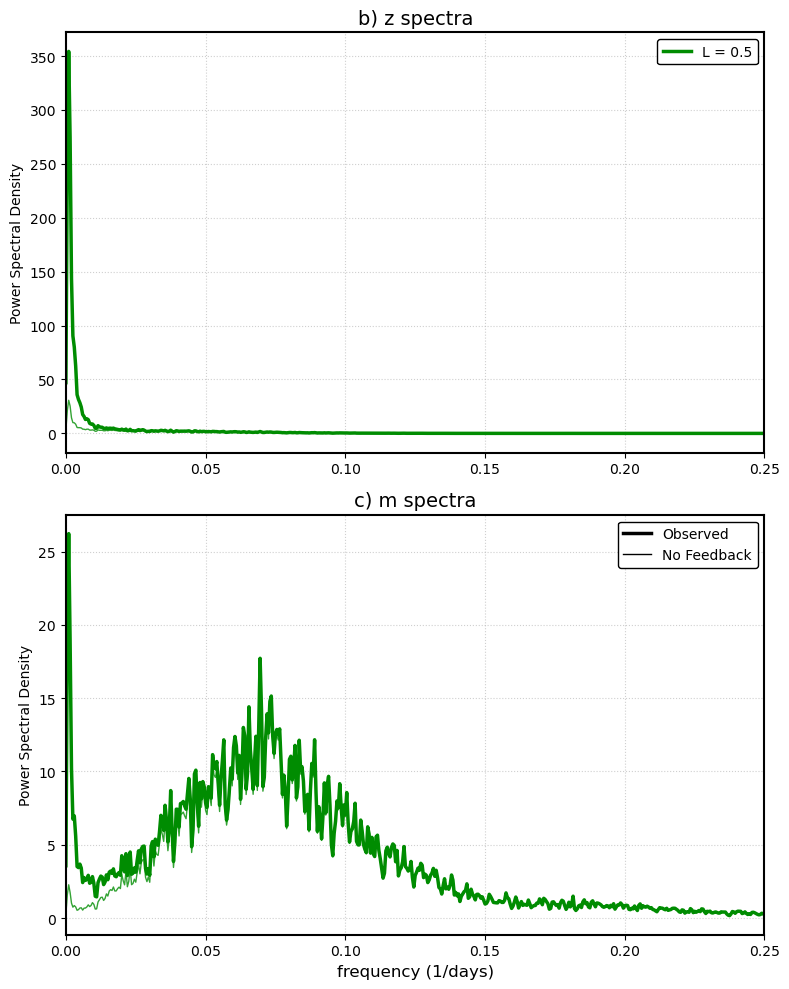

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from matplotlib.lines import Line2D

# 1. Initialize arrays to store the results
num_exp = len(experiments)
Pz_hat_all = np.zeros((num_exp, 501)) 
Pm_hat_all = np.zeros((num_exp, 501))
Pz_obs_all = np.zeros((num_exp, 501))
Pm_obs_all = np.zeros((num_exp, 501))

# YOU MUST FILL THIS IN: 
# Put your calculated feedback strength 'b' scalar for each of the 8 experiments here.
# For example: b_vals = np.array([0.035, 0.032, 0.029, ...])
b_vals = np.zeros(num_exp) 

sigma = np.zeros(num_exp)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
for idx in range(5,6):
    # normalized z and m
    Pz_normalized = (PP_all_u[idx] - PP_all_u[idx].mean()) / PP_all_u[idx].std()
    Pm_normalized = (m_fig3[idx] - m_fig3[idx].mean()) / m_fig3[idx].std()
    
    # --- A. Welch's Method for observed Pz and Pm ---
    freq, Pz_obs = signal.welch(Pz_normalized, fs=0.5, window='hann', 
                                nperseg=lg, noverlap=overlap, scaling='density', detrend='linear')
    _, Pm_obs = signal.welch(Pm_normalized, fs=0.5, window='hann', 
                             nperseg=lg, noverlap=overlap, scaling='density', detrend='linear')
    
    Pz_obs_all[idx] = Pz_obs
    Pm_obs_all[idx] = Pm_obs
    
    # --- B. The paper uses angular frequency (omega) ---
    omega = 2 * np.pi * freq
    
    # --- C. Grab the specific scalar values for this specific experiment ---
    current_tau_inv = 1 / (tau_z_square[idx]**0.5) 
    
    # FIX: Subtract the scalar feedback strength 'b', NOT the time series 'm'
    current_sigma_inv = current_tau_inv - fig4_final[idx]
    
    # Store it if you need it later
    sigma[idx] = 1 / current_sigma_inv
    
    # --- D. Apply Equations C14 and C15 for 'no feedback' spectra ---
    transfer_mag_sq = (current_sigma_inv**2 + omega**2) / (current_tau_inv**2 + omega**2)
    
    Pz_hat = transfer_mag_sq * Pz_obs
    Pm_hat = transfer_mag_sq * Pm_obs
    
    Pz_hat_all[idx] = Pz_hat
    Pm_hat_all[idx] = Pm_hat

    # --- E. Plotting with your custom dictionary configurations ---
    exp = experiments[idx]
    col = exp["color"]
    ls = exp["linestyle"]
    lab = exp["label"]

    # Figure 7b: z spectra 
    # Thick line for observed, thin line for no feedback
    ax1.plot(freq, Pz_obs, color=col, linestyle=ls, linewidth=2.5, label=lab)
    ax1.plot(freq, Pz_hat, color=col, linestyle=ls, linewidth=1.0, alpha=0.8)

    # Figure 7c: m spectra
    ax2.plot(freq, Pm_obs, color=col, linestyle=ls, linewidth=2.5)
    ax2.plot(freq, Pm_hat, color=col, linestyle=ls, linewidth=1.0, alpha=0.8)


# --- F. Plot Formatting ---

# Format ax1 (z spectra)
ax1.set_xlim(0, 0.25)
ax1.set_title('b) z spectra', fontsize=14)
ax1.set_ylabel('Power Spectral Density')
ax1.grid(True, linestyle=':', alpha=0.6)
# Add legend for the experiment colors
ax1.legend(loc='upper right', fontsize=10, framealpha=1, edgecolor='black')

# Format ax2 (m spectra)
ax2.set_xlim(0, 0.25)
ax2.set_title('c) m spectra', fontsize=14)
ax2.set_xlabel('frequency (1/days)', fontsize=12)
ax2.set_ylabel('Power Spectral Density')
ax2.grid(True, linestyle=':', alpha=0.6)

# Add a custom legend to ax2 to explain the thick vs thin lines
custom_lines = [Line2D([0], [0], color='black', lw=2.5),
                Line2D([0], [0], color='black', lw=1.0)]
ax2.legend(custom_lines, ['Observed', 'No Feedback'], loc='upper right', 
           fontsize=10, framealpha=1, edgecolor='black')

plt.tight_layout()
plt.show()

# EMF time filter

In [102]:
import numpy as np
import os
import h5py
from scipy.ndimage import convolve1d

# ==========================================
# 1. Configuration and Setup
# ==========================================
Z_DIM = 20  
Y_DIM = 32  
X_DIM = 128 
STEPS_PER_FILE = 100  # 25 days * 4 steps/day

start_days = range(500, 20000, 25)
base_dir = r"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/HSt42_0/"

total_steps = len(start_days) * STEPS_PER_FILE
print(f"Total files: {len(start_days)}")
print(f"Total 6-hourly steps: {total_steps}")

# ==========================================
# 2. Filter Weights Function (6-hourly adjusted)
# ==========================================
def get_lanczos_weights(cutoff_period_days=10, window_days=20, dt_days=0.25):
    """Generates Lanczos weights adjusted for sub-daily data."""
    # 1. Calculate frequency in cycles per step
    fc = dt_days / cutoff_period_days 
    
    # 2. Calculate window size in steps
    window_n = int(window_days / dt_days) 
    
    k = np.arange(-window_n, window_n + 1)
    weights = 2 * fc * np.sinc(2 * fc * k) * np.sinc(k / window_n)
    weights = weights / weights.sum()
    
    return weights

# ==========================================
# 3. Load Data & Compute Eddies
# ==========================================
# Allocating ~102 GB of RAM!
u_prime_full = np.zeros((total_steps, Z_DIM, Y_DIM, X_DIM), dtype=np.float32)
v_prime_full = np.zeros((total_steps, Z_DIM, Y_DIM, X_DIM), dtype=np.float32)

print("Loading data and computing raw eddies (u', v')...")
current_idx = 0

for day in start_days:
    filename = os.path.join(base_dir, f"RH80_PR0_20000day_startfrom_{day}day_final.dat") 
    
    with h5py.File(filename, 'r') as f:
        # Load the 6-hourly 4D arrays
        raw_u = f["grid_u_c_xyzt"][:,:,32:,:]
        raw_v = f["grid_v_c_xyzt"][:,:,32:,:]
        
        # Calculate eddy component: u' = u - [u]
        # axis=-1 is the X (longitude) dimension
        u_prime_full[current_idx : current_idx + STEPS_PER_FILE] = raw_u - raw_u.mean(axis=-1, keepdims=True)
        v_prime_full[current_idx : current_idx + STEPS_PER_FILE] = raw_v - raw_v.mean(axis=-1, keepdims=True)
        
    current_idx += STEPS_PER_FILE
    print(day)

print("Finished loading.")
del raw_u, raw_v



Total files: 780
Total 6-hourly steps: 78000
Loading data and computing raw eddies (u', v')...
500
525
550
575
600
625
650
675
700
725
750
775
800
825
850
875
900
925
950
975
1000
1025
1050
1075
1100
1125
1150
1175
1200
1225
1250
1275
1300
1325
1350
1375
1400
1425
1450
1475
1500
1525
1550
1575
1600
1625
1650
1675
1700
1725
1750
1775
1800
1825
1850
1875
1900
1925
1950
1975
2000
2025
2050
2075
2100
2125
2150
2175
2200
2225
2250
2275
2300
2325
2350
2375
2400
2425
2450
2475
2500
2525
2550
2575
2600
2625
2650
2675
2700
2725
2750
2775
2800
2825
2850
2875
2900
2925
2950
2975
3000
3025
3050
3075
3100
3125
3150
3175
3200
3225
3250
3275
3300
3325
3350
3375
3400
3425
3450
3475
3500
3525
3550
3575
3600
3625
3650
3675
3700
3725
3750
3775
3800
3825
3850
3875
3900
3925
3950
3975
4000
4025
4050
4075
4100
4125
4150
4175
4200
4225
4250
4275
4300
4325
4350
4375
4400
4425
4450
4475
4500
4525
4550
4575
4600
4625
4650
4675
4700
4725
4750
4775
4800
4825
4850
4875
4900
4925
4950
4975
5000
5025
5050
5075
5100


In [103]:
# ==========================================
# 4. Apply Lanczos Filter to Eddies
# ==========================================
print("Applying 10-day Lanczos filter...")
# Cutoff=10 days, Window=+/-20 days, dt=0.25 days (6-hourly)
weights = get_lanczos_weights(cutoff_period_days=10, window_days=20, dt_days=0.25)

# Low pass is the residual eddy (u'_l)
u_prime_l = convolve1d(u_prime_full, weights, axis=0, mode='reflect')
v_prime_l = convolve1d(v_prime_full, weights, axis=0, mode='reflect')

# High pass is the synoptic eddy (u'_h)
u_prime_h = u_prime_full - u_prime_l
v_prime_h = v_prime_full - v_prime_l

del u_prime_full, v_prime_full 

# ==========================================
# 5. Calculate Zonal Mean Momentum Fluxes
# ==========================================
print("Calculating zonal mean momentum fluxes [u'v']...")

# Calculate fluxes and average across longitude (axis=-1)
synoptic_flux = (u_prime_h * v_prime_h).mean(axis=-1)
residual_flux = (u_prime_l * v_prime_l).mean(axis=-1)

print(f"Final Synoptic Eddy Flux shape: {synoptic_flux.shape}")  
print(f"Final Residual Eddy Flux shape: {residual_flux.shape}")

Applying 10-day Lanczos filter...
Calculating zonal mean momentum fluxes [u'v']...
Final Synoptic Eddy Flux shape: (78000, 20, 32)
Final Residual Eddy Flux shape: (78000, 20, 32)


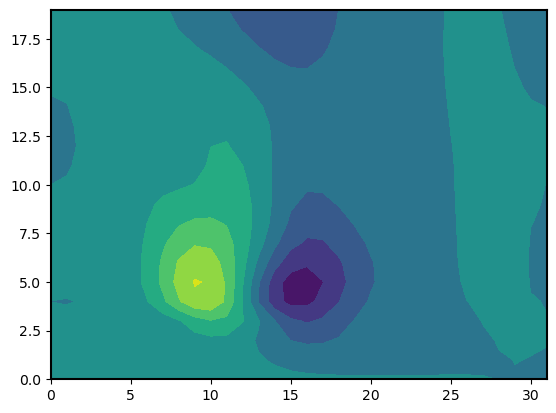

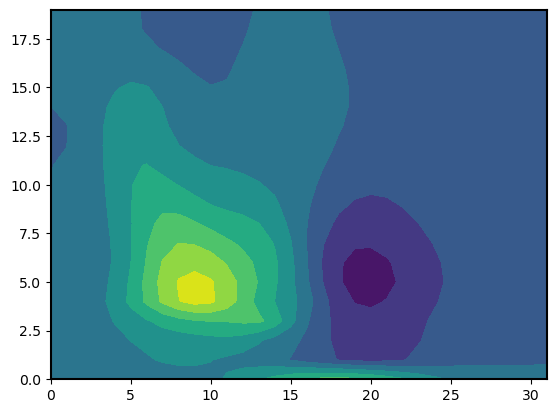

In [104]:
plt.figure()
plt.contourf(synoptic_flux.mean(axis=0))

plt.figure()
plt.contourf(residual_flux.mean(axis=0))


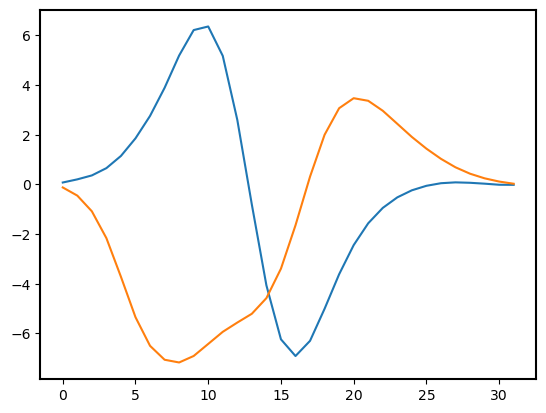

In [108]:
plt.figure()
plt.plot(synoptic_flux.mean(axis=(0,1)))
plt.plot(-residual_flux.mean(axis=(0,1)))


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==========================================
# 1. Compute Flux Convergence (Eddy Forcing)
# ==========================================
def compute_convergence(flux, lat_rad, earth_radius=6371000.0):
    """
    Computes convergence: -(1 / (a * cos^2(lat))) * d/d(lat) [ flux * cos^2(lat) ]
    flux shape: (Time, Z, Lat)
    """
    # Create cos^2(lat) array and reshape for broadcasting across Time and Z
    cos2 = np.cos(lat_rad)**2
    cos2_3d = cos2.reshape(1, 1, -1)
    
    # Multiply flux by cos^2(lat)
    flux_cos2 = flux * cos2_3d
    
    # Take the derivative with respect to latitude (axis=-1)
    # np.gradient needs the actual latitude spacing to compute d(phi) correctly
    grad = np.gradient(flux_cos2, lat_rad, axis=-1)
    
    # Complete the formula
    convergence = -grad / (earth_radius * cos2_3d)
    
    return convergence

# Assume lat_rad is defined (shape: 32,) 
# lat_rad = np.deg2rad(your_lat_array)

print("Computing convergence...")
# Create an evenly spaced array from 0 to 90 degrees with 32 points
lat_deg = np.linspace(0, 90, 32)

# Convert degrees to radians (required for np.cos and np.gradient)
lat_rad = np.deg2rad(lat_deg)

conv_synoptic = compute_convergence(synoptic_flux, lat_rad)
conv_residual = compute_convergence(residual_flux, lat_rad)

# ==========================================
# 2. Vertically Average the Forcing
# ==========================================
# If your idealized dycore uses equal-mass sigma levels, a simple mean works.
# If you use pressure levels, you must weight this mean by pressure thickness (dp/g).
print("Taking vertical average...")
m_synoptic_2d = conv_synoptic.mean(axis=1)  # Shape becomes (78000, 32)
m_residual_2d = conv_residual.mean(axis=1)  # Shape becomes (78000, 32)

# Remove the time-mean to get anomalies (as done in the paper)
m_synoptic_anom = m_synoptic_2d - m_synoptic_2d.mean(axis=0)
m_residual_anom = m_residual_2d - m_residual_2d.mean(axis=0)

# ==========================================
# 3. Project onto EOF1 pattern to get m(t)
# ==========================================
# You must project the anomalies onto your EOF1 pattern.
# We weight the projection by cosine of latitude to account for grid cell area.
# eof1_pattern should be shape (32,)

# 1. EOF Analysis to get PC (Z) and pattern
u_weighted = Uzm_all[0, :, num_lat:] * (cy[num_lat:] ** 0.5)



single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
single_EOF_u.get()

PP_all_u[exp_idx] = single_EOF_u.PC[0] 
EOF_u_final = single_EOF_u.EOF[0]




area_weights = np.cos(lat_rad)
m_synoptic_t = np.dot(m_synoptic_anom * area_weights, EOF_u_final) 
m_residual_t = np.dot(m_residual_anom * area_weights, EOF_u_final)

# ==========================================
# 4. Spectral Analysis (Reproducing Fig 6)
# ==========================================
# Lorenz & Hartmann used: 256 day sections, 128 day overlap, Hanning window
steps_per_day = 4
nperseg = 256 * steps_per_day  # 1024 steps
noverlap = 128 * steps_per_day # 512 steps
fs = steps_per_day             # Sampling frequency = 4 cycles/day

freq_syn, power_syn = welch(m_synoptic_t, fs=fs, window='hann', 
                            nperseg=nperseg, noverlap=noverlap)

freq_res, power_res = welch(m_residual_t, fs=fs, window='hann', 
                            nperseg=nperseg, noverlap=noverlap)

# ==========================================
# 5. Plotting Fig 6a and 6b
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# Figure 6a: Synoptic Eddy Forcing Spectrum
ax1.plot(freq_syn, power_syn, color='black', linewidth=2)
ax1.set_xlim(0, 0.25)
ax1.set_title('a) synoptic eddy forcing spectrum', loc='left', fontsize=12)
ax1.set_ylabel('Power Density')
ax1.grid(True, linestyle='--', alpha=0.6)

# Figure 6b: Residual Eddy Forcing Spectrum
ax2.plot(freq_res, power_res, color='black', linewidth=2)
ax2.set_xlim(0, 0.25)
ax2.set_title('b) residual eddy forcing spectrum', loc='left', fontsize=12)
ax2.set_xlabel('frequency (1/days)')
ax2.set_ylabel('Power Density')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Computing convergence...
Taking vertical average...


NameError: name 'Uzm_all' is not defined

In [114]:
EOF_u_final.shape

(32,)

In [22]:
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d
from scipy.signal import welch

# ==========================================
# 1. Configuration and Setup
# ==========================================
Z_DIM = 20  
Y_DIM = 32  
X_DIM = 128 
DAYS_PER_FILE = 25  # Reverting back to days instead of steps

start_days = range(500, 20000, 25)
base_dir = r"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/HSt42_0/"

total_days = len(start_days) * DAYS_PER_FILE
print(f"Total files: {len(start_days)}")
print(f"Total daily steps: {total_days}")

# ==========================================
# 2. Filter Weights Function (Daily Data - 41 Weights)
# ==========================================
def get_lanczos_weights(cutoff_period_days=10, window_days=20):
    """Generates 41 Lanczos weights for daily data."""
    fc = 1.0 / cutoff_period_days 
    k = np.arange(-window_days, window_days + 1)
    
    weights = 2 * fc * np.sinc(2 * fc * k) * np.sinc(k / window_days)
    weights = weights / weights.sum()
    
    return weights

# ==========================================
# 3. Load Data, Average to Daily, & Compute Eddies
# ==========================================
# Allocating ~25 GB of RAM (much safer!)
u_prime_full = np.zeros((total_days, Z_DIM, Y_DIM, X_DIM), dtype=np.float32)
v_prime_full = np.zeros((total_days, Z_DIM, Y_DIM, X_DIM), dtype=np.float32)

print("Loading data, computing daily means, and calculating raw eddies (u', v')...")
current_idx = 0

for day in start_days:
    filename = os.path.join(base_dir, f"RH80_PR0_20000day_startfrom_{day}day_final.dat") 
    
    with h5py.File(filename, 'r') as f:
        # Load the 6-hourly 4D arrays
        raw_u_6h = f["grid_u_c_xyzt"][:, :, 32:, :]
        raw_v_6h = f["grid_v_c_xyzt"][:, :, 32:, :]
        
        # 1. Reshape to separate days and the 4 daily steps: (25, 4, 20, 32, 128)
        # 2. Mean across axis=1 (the 4 daily steps) to get daily data
        raw_u_daily = raw_u_6h.reshape(DAYS_PER_FILE, 4, Z_DIM, Y_DIM, X_DIM).mean(axis=1)
        raw_v_daily = raw_v_6h.reshape(DAYS_PER_FILE, 4, Z_DIM, Y_DIM, X_DIM).mean(axis=1)
        
        # Calculate eddy component: u' = u - [u]
        # axis=-1 is the X (longitude) dimension
        u_prime_full[current_idx : current_idx + DAYS_PER_FILE] = raw_u_daily - raw_u_daily.mean(axis=-1, keepdims=True)
        v_prime_full[current_idx : current_idx + DAYS_PER_FILE] = raw_v_daily - raw_v_daily.mean(axis=-1, keepdims=True)
        
    current_idx += DAYS_PER_FILE
    if day % 2500 == 0:
        print(f"Processed up to day {day}...")

print("Finished loading.")

# ==========================================
# 4. Apply Lanczos Filter to Eddies
# ==========================================
print("Applying 10-day Lanczos filter...")
# Cutoff=10 days, Window=+/-20 days -> perfectly yields 41 weights 
weights = get_lanczos_weights(cutoff_period_days=10, window_days=20)

# Low pass is the residual eddy (u'_l)
u_prime_l = convolve1d(u_prime_full, weights, axis=0, mode='reflect')
v_prime_l = convolve1d(v_prime_full, weights, axis=0, mode='reflect')

# High pass is the synoptic eddy (u'_h)
u_prime_h = u_prime_full - u_prime_l
v_prime_h = v_prime_full - v_prime_l

del u_prime_full, v_prime_full 

# ==========================================
# 5. Calculate Zonal Mean Momentum Fluxes
# ==========================================
print("Calculating zonal mean momentum fluxes [u'v']...")
synoptic_flux = (u_prime_h * v_prime_h).mean(axis=-1)
residual_flux = (u_prime_l * v_prime_l).mean(axis=-1)

# ==========================================
# 6. Compute Flux Convergence (Eddy Forcing)
# ==========================================
def compute_convergence(flux, lat_rad, earth_radius=6371000.0):
    cos2 = np.cos(lat_rad)**2
    cos2_3d = cos2.reshape(1, 1, -1)
    flux_cos2 = flux * cos2_3d
    grad = np.gradient(flux_cos2, lat_rad, axis=-1)
    convergence = -grad / (earth_radius * cos2_3d)
    return convergence

print("Computing convergence...")
lat_deg = np.linspace(0, 90, 32)
lat_rad = np.deg2rad(lat_deg)

conv_synoptic = compute_convergence(synoptic_flux, lat_rad)
conv_residual = compute_convergence(residual_flux, lat_rad)

# ==========================================
# 7. Vertically Average the Forcing
# ==========================================
print("Taking vertical average...")
m_synoptic_2d = conv_synoptic.mean(axis=1)  
m_residual_2d = conv_residual.mean(axis=1)  

# Remove the time-mean to get anomalies
m_synoptic_anom = m_synoptic_2d - m_synoptic_2d.mean(axis=0)
m_residual_anom = m_residual_2d - m_residual_2d.mean(axis=0)

# ==========================================
# 8. Project onto EOF1 pattern to get m(t)
# ==========================================
# NOTE: Ensure your EOF_u_final is defined before this step! 
# In your snippet, you used EOF from the 'eofs' package. 
# Assuming EOF_u_final is a 1D array of shape (32,)
area_weights = np.cos(lat_rad)
m_synoptic_t = np.dot(m_synoptic_anom * area_weights, EOF_u_final) 
m_residual_t = np.dot(m_residual_anom * area_weights, EOF_u_final)

# ==========================================
# 9. Spectral Analysis (Reproducing Fig 6)
# ==========================================
# Lorenz & Hartmann used 256 day sections overlapped by 128 days [cite: 69]
nperseg = 256 
noverlap = 128 
fs = 1.0  # Sampling frequency = 1 cycle/day since data is now daily

freq_syn, power_syn = welch(m_synoptic_t, fs=fs, window='hann', 
                            nperseg=nperseg, noverlap=noverlap)

freq_res, power_res = welch(m_residual_t, fs=fs, window='hann', 
                            nperseg=nperseg, noverlap=noverlap)



Total files: 780
Total daily steps: 19500
Loading data, computing daily means, and calculating raw eddies (u', v')...


KeyboardInterrupt: 

In [120]:
# Define the save path
save_path_npz = os.path.join(base_dir, r"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_power_spectra_PR0.npz")

print(f"Saving power spectra to {save_path_npz}...")
# We also save the frequency arrays so you have the x-axis for future plotting
np.savez(save_path_npz, 
         freq_syn=freq_syn, 
         P_synoptic=power_syn, 
         freq_res=freq_res, 
         P_residual=power_res)

print("Saved successfully!")

# How to load it later:
# data = np.load("eddy_power_spectra.npz")
# P_synoptic_loaded = data['P_synoptic']

Saving power spectra to /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_power_spectra_PR0.npz...
Saved successfully!


In [124]:
synoptic_flux.shape

(19500, 20, 32)

In [ ]:
m_residual_anom

In [36]:
import h5py

# Define the path to your saved HDF5 file
file_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_Trop.h5"

print(f"Reading data from {file_path}...\n")

with h5py.File(file_path, 'r') as f:
    # 1. Load 1D Power Spectra arrays
    freq_syn = f["freq_syn"][:]
    P_synoptic = f["P_synoptic"][:]
    freq_res = f["freq_res"][:]
    P_residual = f["P_residual"][:]
    
    # 2. Load the 1D m(t) time series (eddy forcing projected onto EOF1)
    m_synoptic_t = f["m_synoptic_t"][:]
    m_residual_t = f["m_residual_t"][:]
    
    # 3. Load the full 3D zonal-mean momentum fluxes [u'v'] (Time, Z, Y)
    synoptic_flux = f["synoptic_flux"][:]
    residual_flux = f["residual_flux"][:]

    # 4. Load the full 3D eddy momentum flux convergence (dmdy) (Time, Z, Y)
    conv_synoptic = f["conv_synoptic"][:]
    conv_residual = f["conv_residual"][:]

    # 5. Load the EOF1 spatial pattern
    EOF1_pattern = f["EOF1_pattern"][:]

# ==========================================
# Print shapes to verify successful loading
# ==========================================
print("Data loaded successfully! Here are the shapes:")
print("-" * 45)
print(f"freq_syn:      {freq_syn.shape}")
print(f"P_synoptic:    {P_synoptic.shape}")
print(f"freq_res:      {freq_res.shape}")
print(f"P_residual:    {P_residual.shape}")
print("-" * 45)
print(f"m_synoptic_t:  {m_synoptic_t.shape}")
print(f"m_residual_t:  {m_residual_t.shape}")
print("-" * 45)
print(f"synoptic_flux: {synoptic_flux.shape}")  # Expected: (19500, 20, 32)
print(f"residual_flux: {residual_flux.shape}")  # Expected: (19500, 20, 32)
print(f"conv_synoptic: {conv_synoptic.shape}")  # Expected: (19500, 20, 32)
print(f"conv_residual: {conv_residual.shape}")  # Expected: (19500, 20, 32)
print("-" * 45)
print(f"EOF1_pattern:  {EOF1_pattern.shape}")    # Expected: (32,)

Reading data from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_Trop.h5...

Data loaded successfully! Here are the shapes:
---------------------------------------------
freq_syn:      (129,)
P_synoptic:    (129,)
freq_res:      (129,)
P_residual:    (129,)
---------------------------------------------
m_synoptic_t:  (19500,)
m_residual_t:  (19500,)
---------------------------------------------
synoptic_flux: (19500, 20, 32)
residual_flux: (19500, 20, 32)
conv_synoptic: (19500, 20, 32)
conv_residual: (19500, 20, 32)
---------------------------------------------
EOF1_pattern:  (32,)


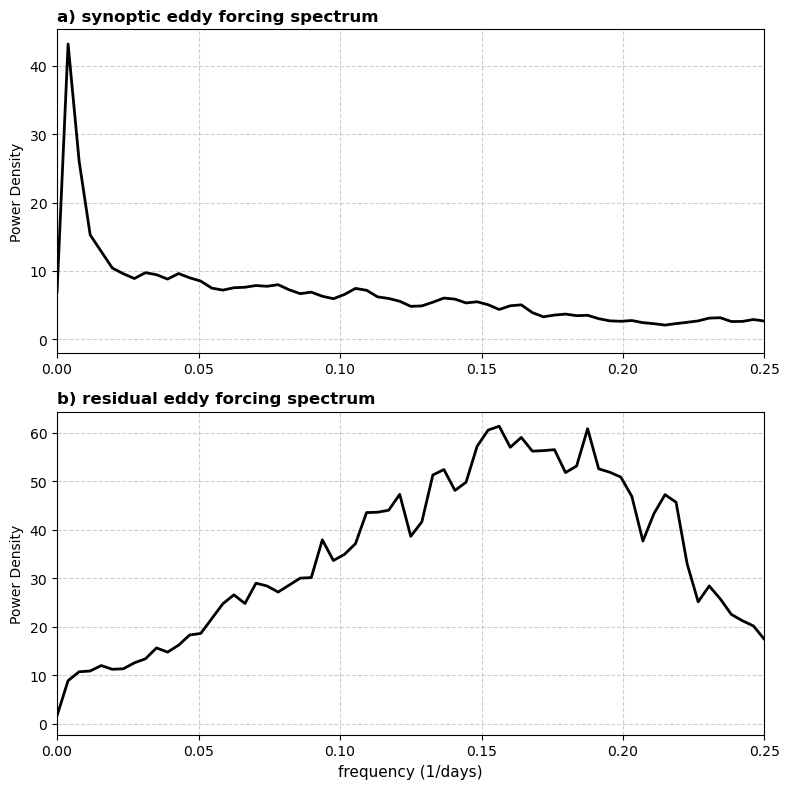

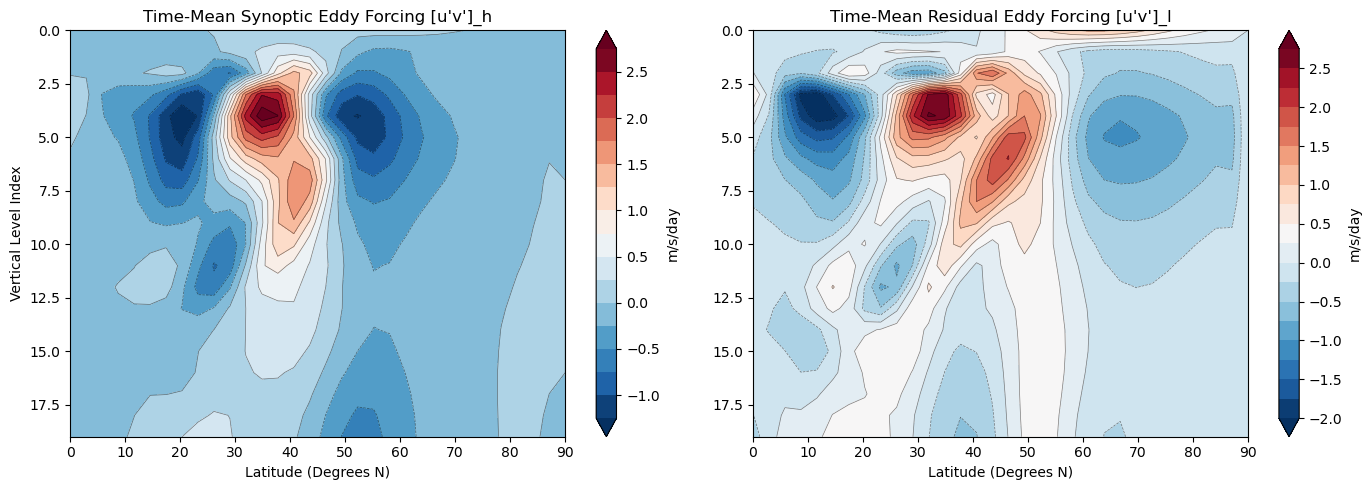

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming the data from the previous step is already loaded into your environment:
# freq_syn, P_synoptic, freq_res, P_residual
# conv_synoptic, conv_residual

# ==========================================
# Figure 1: Power Spectra (Recreating LH2001 Fig 6)
# ==========================================
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# Figure 6a: Synoptic Eddy Forcing Spectrum
ax1.plot(freq_syn, P_synoptic, color='black', linewidth=2)
ax1.set_xlim(0, 0.25) # Match the LH2001 axis limits
ax1.set_title('a) synoptic eddy forcing spectrum', loc='left', fontsize=12, fontweight='bold')
ax1.set_ylabel('Power Density')
ax1.grid(True, linestyle='--', alpha=0.6)

# Figure 6b: Residual Eddy Forcing Spectrum
ax2.plot(freq_res, P_residual, color='black', linewidth=2)
ax2.set_xlim(0, 0.25)
ax2.set_title('b) residual eddy forcing spectrum', loc='left', fontsize=12, fontweight='bold')
ax2.set_xlabel('frequency (1/days)', fontsize=11)
ax2.set_ylabel('Power Density')
ax2.grid(True, linestyle='--', alpha=0.6)

fig1.tight_layout()
plt.show()

# ==========================================
# Figure 2: Time-Mean Latitude-Height Cross-Sections
# ==========================================
# Calculate the time-mean of the 3D arrays (axis=0 is time)
mean_conv_synoptic = conv_synoptic.mean(axis=0) * 86400  # Convert to m/s/day for readability
mean_conv_residual = conv_residual.mean(axis=0) * 86400

# Create dummy axes for plotting (Adjust Z_levels to match your actual model vertical coordinates)
latitudes = np.linspace(0, 90, 32)
Z_levels = np.arange(20) # Dummy 0-19 vertical index

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Synoptic Convergence
# Using a diverging colormap (RdBu_r) where red is positive forcing (westerly acceleration)
c1 = ax3.contourf(latitudes, Z_levels, mean_conv_synoptic, levels=20, cmap='RdBu_r', extend='both')
ax3.contour(latitudes, Z_levels, mean_conv_synoptic, levels=20, colors='k', linewidths=0.5, alpha=0.5)
ax3.set_title('Time-Mean Synoptic Eddy Forcing [u\'v\']_h', fontsize=12)
ax3.set_xlabel('Latitude (Degrees N)')
ax3.set_ylabel('Vertical Level Index')
ax3.invert_yaxis() # Invert if Z index 0 is the top of the atmosphere
fig2.colorbar(c1, ax=ax3, label='m/s/day')

# Plot Residual Convergence
c2 = ax4.contourf(latitudes, Z_levels, mean_conv_residual, levels=21, cmap='RdBu_r', extend='both')
ax4.contour(latitudes, Z_levels, mean_conv_residual, levels=21, colors='k', linewidths=0.5, alpha=0.5)
ax4.set_title('Time-Mean Residual Eddy Forcing [u\'v\']_l', fontsize=12)
ax4.set_xlabel('Latitude (Degrees N)')
ax4.invert_yaxis()
fig2.colorbar(c2, ax=ax4, label='m/s/day')

fig2.tight_layout()
plt.show()

In [19]:
EOF1_pattern.shape

(32,)

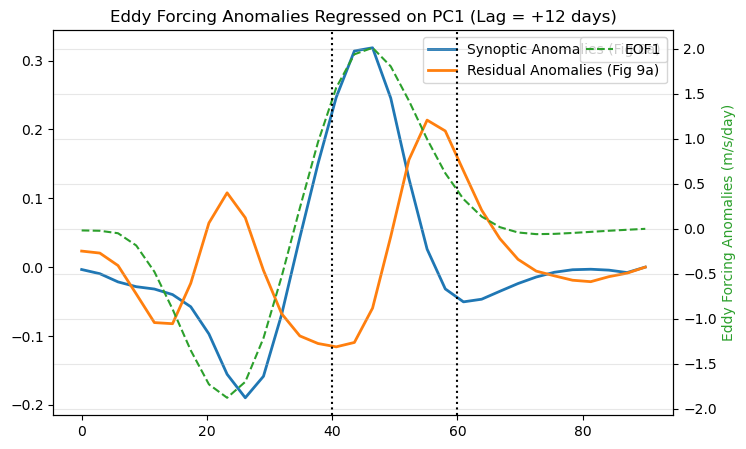

In [35]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data from your newly generated file
file_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_Trop.h5"

with h5py.File(file_path, 'r') as f:
    conv_syn = f["conv_synoptic"][:]
    conv_res = f["conv_residual"][:]
    PC1 = f["PC1"][:]
    EOF1 = f["EOF1_pattern"][:]

# Generate latitudes
lat_deg = np.linspace(0, 90, 32)

# 2. Take the vertical mean (axis=1 is Z)
m_syn_2d = conv_syn.mean(axis=1)
m_res_2d = conv_res.mean(axis=1)

# 3. Remove the time-mean to get ANOMALIES (axis=0 is Time)
m_syn_anom = m_syn_2d - m_syn_2d.mean(axis=0)
m_res_anom = m_res_2d - m_res_2d.mean(axis=0)

# 4. Standardize PC1 so the regression units are (m/s/day per 1 std of PC1)
PC1_std = (PC1 - PC1.mean()) / PC1.std()

# 5. Perform the 12-day Lagged Regression (PC1 leads by 12 days)
lag = 12
pc_shifted = PC1_std[:-lag]           # PC1 from day 0 to end-12
syn_shifted = m_syn_anom[lag:, :]     # Forcing from day 12 to end
res_shifted = m_res_anom[lag:, :]

# Linear regression: sum(x*y) / sum(x^2)
reg_syn = np.sum(pc_shifted[:, None] * syn_shifted, axis=0) / np.sum(pc_shifted**2)
reg_res = np.sum(pc_shifted[:, None] * res_shifted, axis=0) / np.sum(pc_shifted**2)

# Convert to m/s/day
reg_syn *= 86400
reg_res *= 86400

# ==========================================
# 6. Plotting Figures 8a and 9a
# ==========================================
plt.figure(figsize=(8, 5))

# Plot the regressed anomalies
plt.plot(lat_deg, reg_syn, label="Synoptic Anomalies (Fig 8a)", color='tab:blue', linewidth=2)
plt.plot(lat_deg, reg_res, label="Residual Anomalies (Fig 9a)", color='tab:orange', linewidth=2)
plt.legend()

# Plot EOF1 on a secondary y-axis to compare the shape
ax2 = plt.gca().twinx()
ax2.plot(lat_deg, EOF1, label="EOF1", color='tab:green', linestyle='--')
ax2.set_ylabel("EOF1 Wind Pattern", color='tab:green')

# Add vertical reference lines
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")

plt.title("Eddy Forcing Anomalies Regressed on PC1 (Lag = +12 days)")
plt.xlabel("Latitude (Degrees N)")
plt.gca().set_ylabel("Eddy Forcing Anomalies (m/s/day)")

# Combine legends
lines_1, labels_1 = plt.gca().get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Loading and plotting PR0...
Loading and plotting PR10...
Loading and plotting PR20...
Loading and plotting PR30...
Loading and plotting PR40...
Loading and plotting PR50...
Loading and plotting Midlat...
Loading and plotting Trop...


/tmp/ipykernel_2980950/1578039103.py:148: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_spec.show()
/tmp/ipykernel_2980950/1578039103.py:161: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_reg.show()
/tmp/ipykernel_2980950/1578039103.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_2d.show()


All plots generated with colorbars!


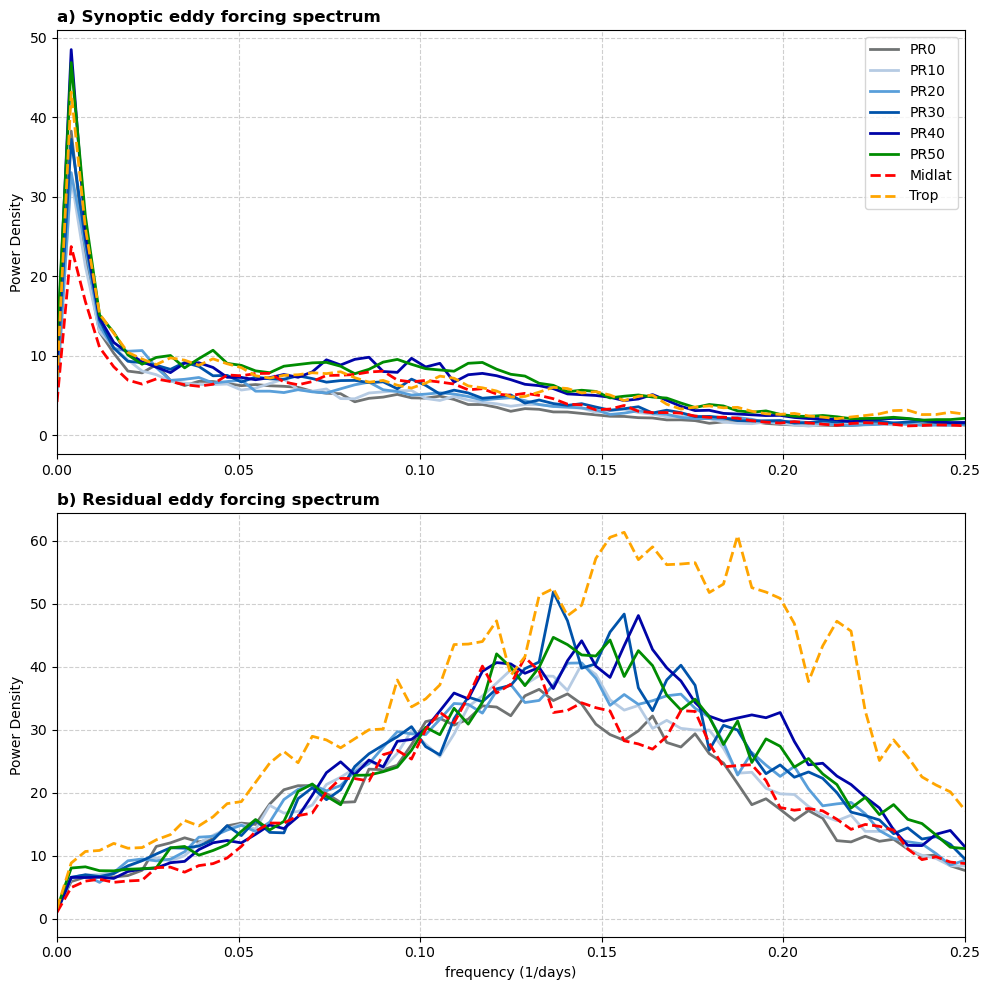

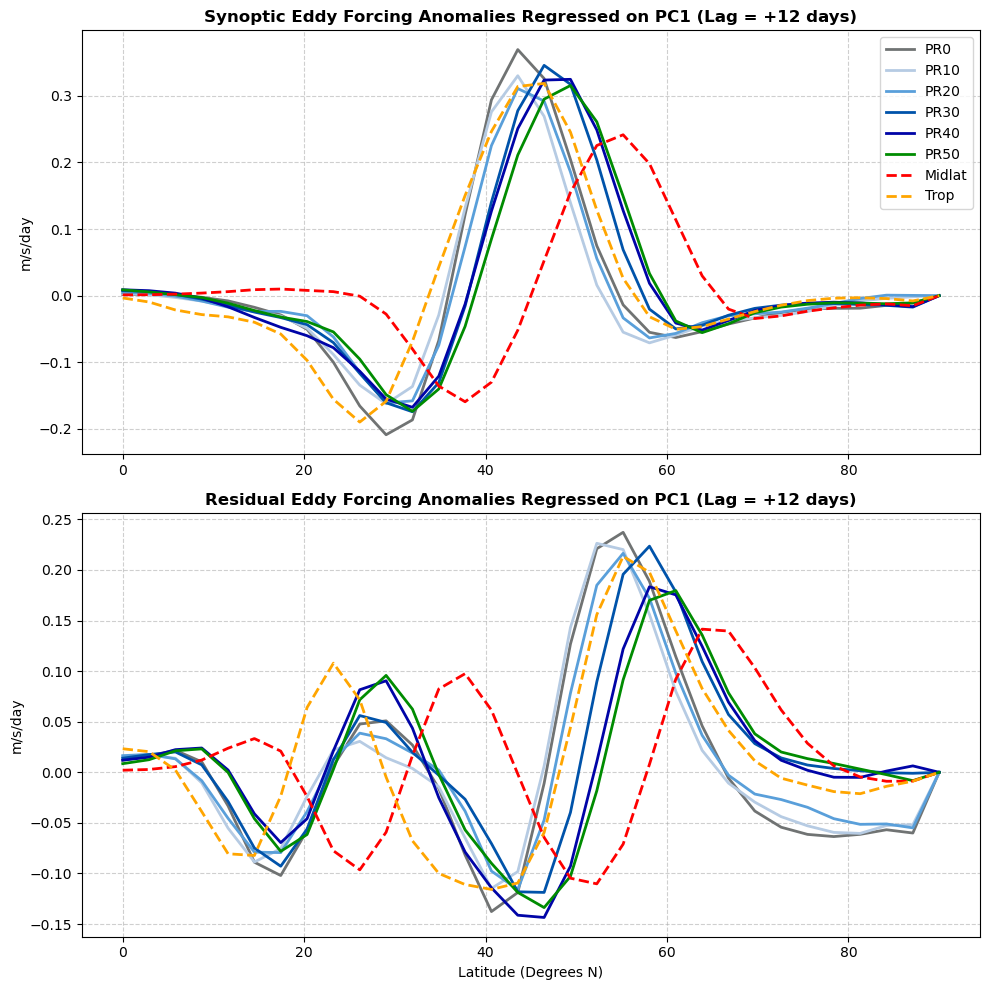

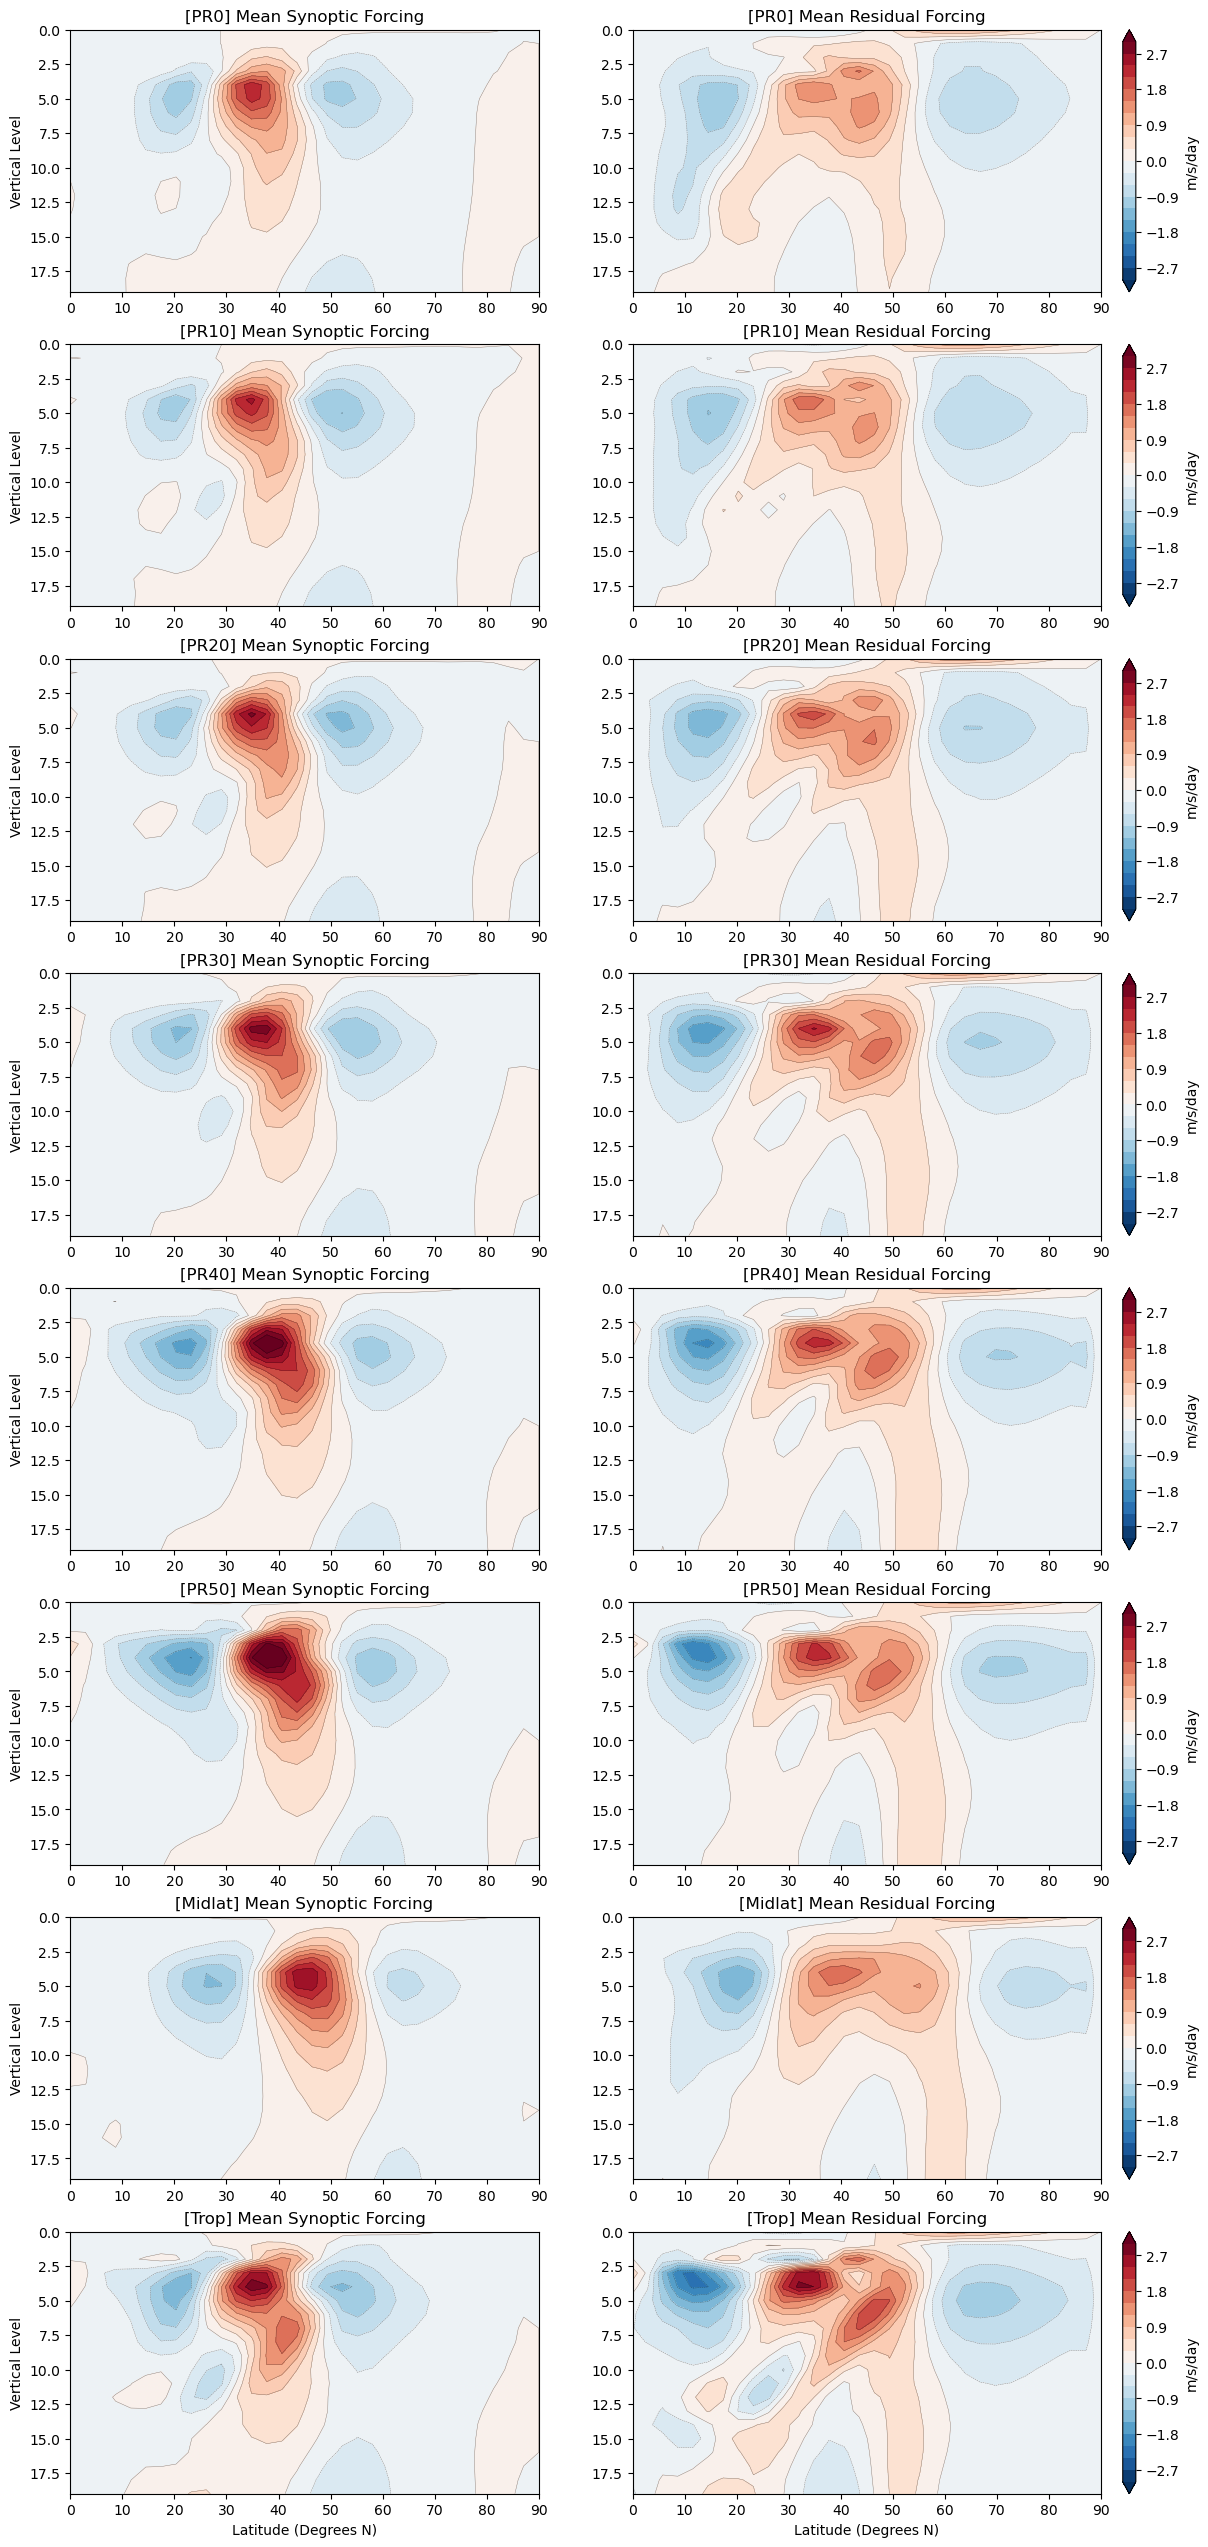

In [49]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. Configuration & Experiment Setup
# ==========================================
experiments = []
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"PR{val}",
        "color": col,
        "linestyle": "-",
        "file_path": f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_PR{val}.h5"
    })

experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--",
    "file_path": "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_Midlat.h5"
})

experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "file_path": "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_Trop.h5"
})

lat_deg = np.linspace(0, 90, 32)
Z_levels = np.arange(20)

# Initialize Figures
fig_spec, (ax_spec_syn, ax_spec_res) = plt.subplots(2, 1, figsize=(10, 10))
fig_reg, (ax_reg_syn, ax_reg_res) = plt.subplots(2, 1, figsize=(10, 10))
fig_2d, axes_2d = plt.subplots(len(experiments), 2, figsize=(14, 4 * len(experiments))) # Widened slightly for colorbars

# ==========================================
# 2. Main Loop Over Experiments
# ==========================================
for idx, exp in enumerate(experiments):
    label = exp["label"]
    color = exp["color"]
    ls = exp["linestyle"]
    
    print(f"Loading and plotting {label}...")
    
    with h5py.File(exp["file_path"], 'r') as f:
        # Load Spectra
        freq_syn = f["freq_syn"][:]
        P_synoptic = f["P_synoptic"][:]
        freq_res = f["freq_res"][:]
        P_residual = f["P_residual"][:]
        
        # Load Convergence and PC1
        conv_syn = f["conv_synoptic"][:]
        conv_res = f["conv_residual"][:]
        PC1 = f["PC1"][:]
        
    # ------------------------------------------
    # Plotting 1: Power Spectra
    # ------------------------------------------
    ax_spec_syn.plot(freq_syn, P_synoptic, label=label, color=color, linestyle=ls, linewidth=2)
    ax_spec_res.plot(freq_res, P_residual, label=label, color=color, linestyle=ls, linewidth=2)
    
    # ------------------------------------------
    # Plotting 2: Lagged Regressions (Lag = +12)
    # ------------------------------------------
    m_syn_2d = conv_syn.mean(axis=1)
    m_res_2d = conv_res.mean(axis=1)

    m_syn_anom = m_syn_2d - m_syn_2d.mean(axis=0)
    m_res_anom = m_res_2d - m_res_2d.mean(axis=0)

    PC1_std = (PC1 - PC1.mean()) / PC1.std()

    lag = 12
    pc_shifted = PC1_std[:-lag]
    syn_shifted = m_syn_anom[lag:, :]
    res_shifted = m_res_anom[lag:, :]

    reg_syn = np.sum(pc_shifted[:, None] * syn_shifted, axis=0) / np.sum(pc_shifted**2) * 86400
    reg_res = np.sum(pc_shifted[:, None] * res_shifted, axis=0) / np.sum(pc_shifted**2) * 86400

    if exp["label"] == "PR10":
        ax_reg_syn.plot(lat_deg, -reg_syn, label=label, color=color, linestyle=ls, linewidth=2)
        ax_reg_res.plot(lat_deg, -reg_res, label=label, color=color, linestyle=ls, linewidth=2)
    elif exp["label"] == "PR40":
        ax_reg_syn.plot(lat_deg, -reg_syn, label=label, color=color, linestyle=ls, linewidth=2)
        ax_reg_res.plot(lat_deg, -reg_res, label=label, color=color, linestyle=ls, linewidth=2)
    elif exp["label"] == "Midlat":
        ax_reg_syn.plot(lat_deg, -reg_syn, label=label, color=color, linestyle=ls, linewidth=2)
        ax_reg_res.plot(lat_deg, -reg_res, label=label, color=color, linestyle=ls, linewidth=2)
    else:
        ax_reg_syn.plot(lat_deg, reg_syn, label=label, color=color, linestyle=ls, linewidth=2)
        ax_reg_res.plot(lat_deg, reg_res, label=label, color=color, linestyle=ls, linewidth=2)
        

    # ------------------------------------------
    # Plotting 3: 2D Time-Mean Cross-Sections
    # ------------------------------------------
    mean_conv_syn = conv_syn.mean(axis=0) * 86400
    mean_conv_res = conv_res.mean(axis=0) * 86400
    
    ax_syn_2d = axes_2d[idx, 0]
    ax_res_2d = axes_2d[idx, 1]
    
    vmax = max(np.abs(mean_conv_syn).max(), np.abs(mean_conv_res).max())
    levels = np.linspace(-3, 3, 21)
    
    c1 = ax_syn_2d.contourf(lat_deg, Z_levels, mean_conv_syn, levels=levels, cmap='RdBu_r', extend='both')
    ax_syn_2d.contour(lat_deg, Z_levels, mean_conv_syn, levels=levels, colors='k', linewidths=0.3, alpha=0.5)
    ax_syn_2d.set_title(f'[{label}] Mean Synoptic Forcing', fontsize=12)
    ax_syn_2d.set_ylabel('Vertical Level')
    ax_syn_2d.invert_yaxis()
    
    c2 = ax_res_2d.contourf(lat_deg, Z_levels, mean_conv_res, levels=levels, cmap='RdBu_r', extend='both')
    ax_res_2d.contour(lat_deg, Z_levels, mean_conv_res, levels=levels, colors='k', linewidths=0.3, alpha=0.5)
    ax_res_2d.set_title(f'[{label}] Mean Residual Forcing', fontsize=12)
    ax_res_2d.invert_yaxis()
    
    # NEW: Add a shared colorbar for this specific row
    cbar = fig_2d.colorbar(c2, ax=[ax_syn_2d, ax_res_2d], fraction=0.03, pad=0.02)
    cbar.set_label('m/s/day')

# ==========================================
# 3. Finalize Plot Formatting
# ==========================================
ax_spec_syn.set_xlim(0, 0.25)
ax_spec_syn.set_title('a) Synoptic eddy forcing spectrum', loc='left', fontweight='bold')
ax_spec_syn.set_ylabel('Power Density')
ax_spec_syn.grid(True, linestyle='--', alpha=0.6)
ax_spec_syn.legend(loc='upper right')

ax_spec_res.set_xlim(0, 0.25)
ax_spec_res.set_title('b) Residual eddy forcing spectrum', loc='left', fontweight='bold')
ax_spec_res.set_xlabel('frequency (1/days)')
ax_spec_res.set_ylabel('Power Density')
ax_spec_res.grid(True, linestyle='--', alpha=0.6)

fig_spec.tight_layout()
fig_spec.show()

ax_reg_syn.set_title('Synoptic Eddy Forcing Anomalies Regressed on PC1 (Lag = +12 days)', fontweight='bold')
ax_reg_syn.set_ylabel('m/s/day')
ax_reg_syn.grid(True, linestyle='--', alpha=0.6)
ax_reg_syn.legend(loc='upper right')

ax_reg_res.set_title('Residual Eddy Forcing Anomalies Regressed on PC1 (Lag = +12 days)', fontweight='bold')
ax_reg_res.set_xlabel('Latitude (Degrees N)')
ax_reg_res.set_ylabel('m/s/day')
ax_reg_res.grid(True, linestyle='--', alpha=0.6)

fig_reg.tight_layout()
fig_reg.show()

axes_2d[-1, 0].set_xlabel('Latitude (Degrees N)')
axes_2d[-1, 1].set_xlabel('Latitude (Degrees N)')
fig_2d.show()

print("All plots generated with colorbars!")

Loading and plotting PR0...
Loading and plotting PR50...
Loading and plotting Midlat...
Loading and plotting Trop...


/tmp/ipykernel_2980950/3125708909.py:177: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_spec.show()
/tmp/ipykernel_2980950/3125708909.py:195: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_reg.show()
/tmp/ipykernel_2980950/3125708909.py:200: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_2d.show()


All plots generated successfully!


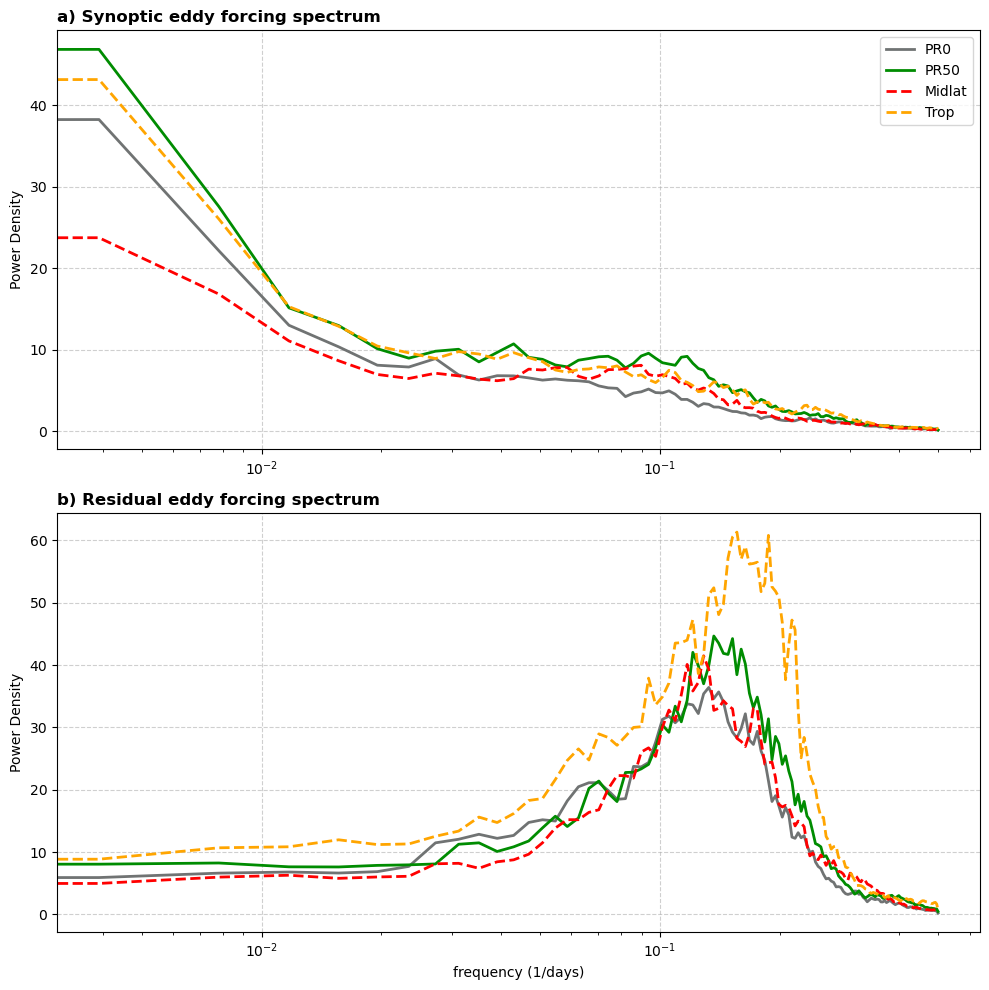

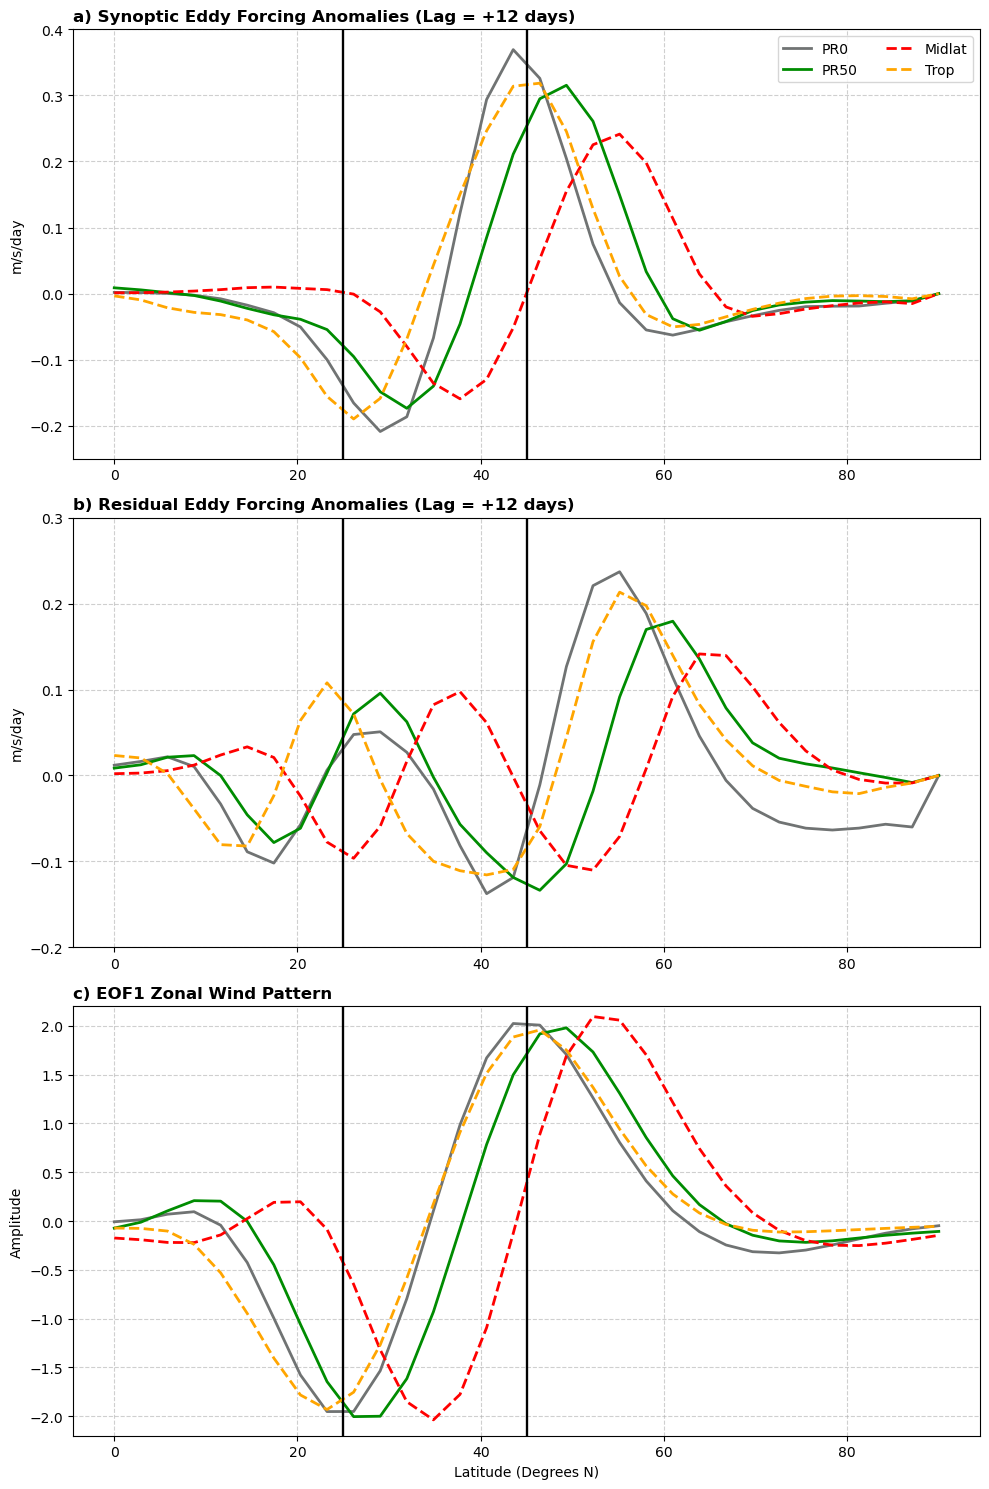

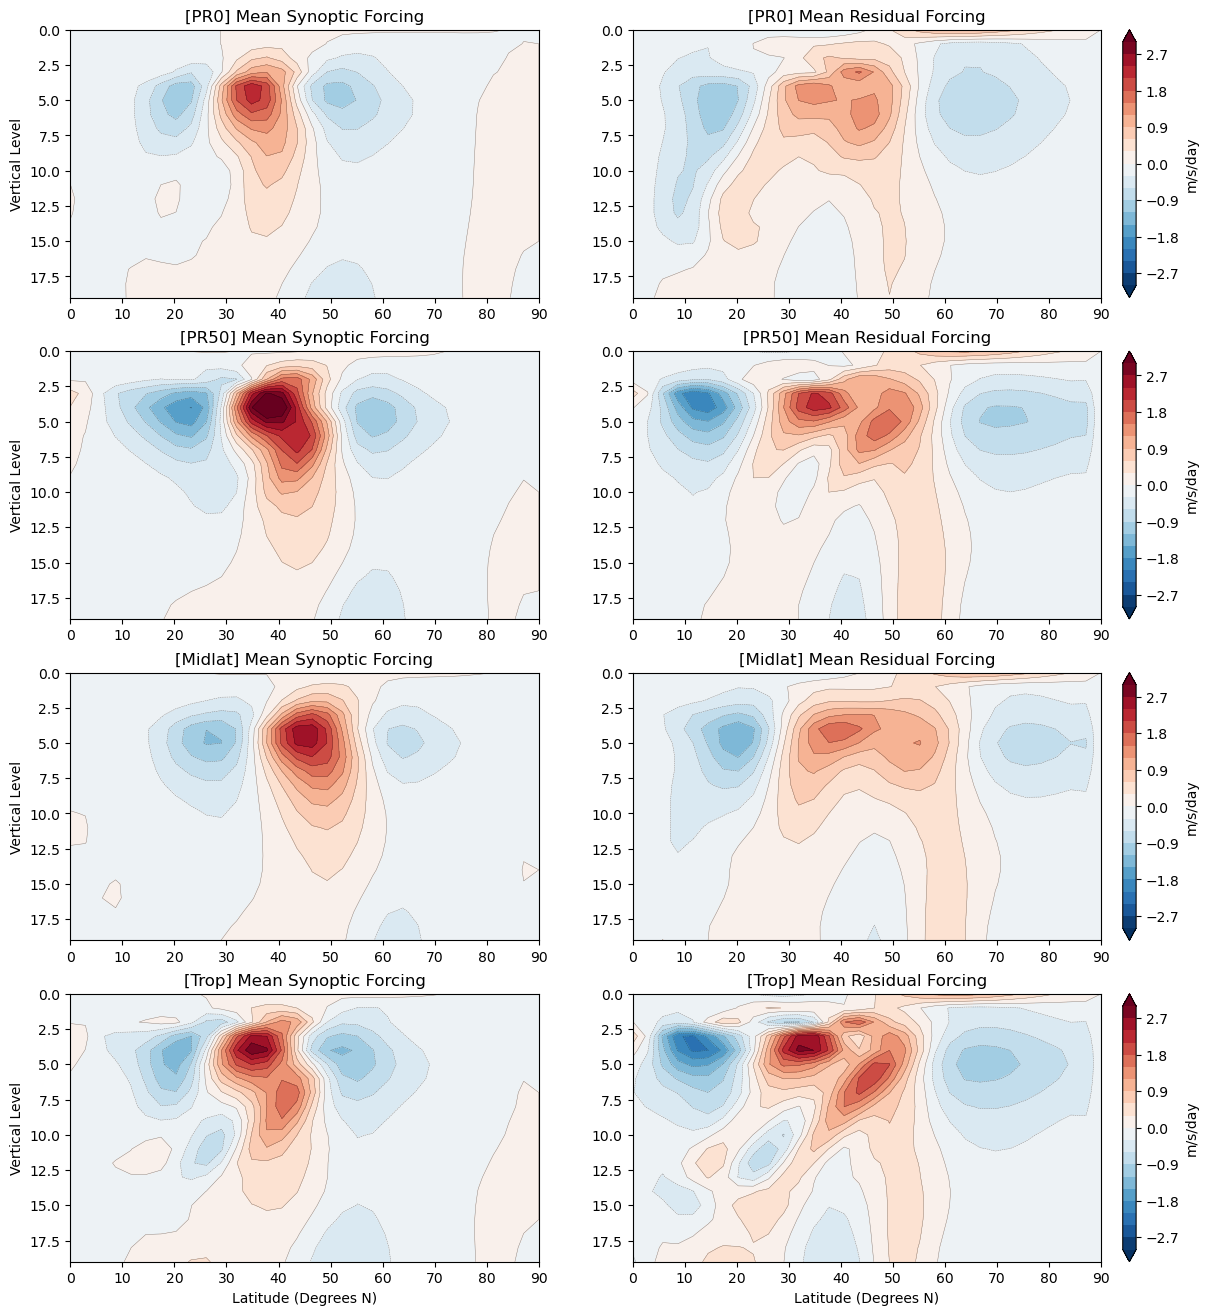

In [66]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. Configuration & Experiment Setup
# ==========================================
experiments = []
# PR_values = [0, 10, 20, 30, 40, 50]
PR_values = [0, 50]

# pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      # [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

pr_colors = np.array([[112, 115, 115], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"PR{val}",
        "color": col,
        "linestyle": "-",
        "file_path": f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_PR{val}.h5"
    })

experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--",
    "file_path": "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_Midlat.h5"
})

experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "file_path": "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/eddy_fluxes_and_spectra_Trop.h5"
})

lat_deg = np.linspace(0, 90, 32)
Z_levels = np.arange(20)

# Initialize Figures
# Fig 1: Power Spectra
fig_spec, (ax_spec_syn, ax_spec_res) = plt.subplots(2, 1, figsize=(10, 10))

# Fig 2: Spatial Anomalies (3 PANELS: Synoptic, Residual, and EOF1)
fig_reg, (ax_reg_syn, ax_reg_res, ax_reg_eof) = plt.subplots(3, 1, figsize=(10, 15))

# Fig 3: 2D Time-Mean Cross-Sections (8 rows x 2 cols)
fig_2d, axes_2d = plt.subplots(len(experiments), 2, figsize=(14, 4 * len(experiments)))

# List of experiments that need their EOF phase flipped to align with the others
# Adjust this list if you need to add PR20 or remove PR10!
flip_experiments = ["PR10", "PR40", "Midlat"] 

# ==========================================
# 2. Main Loop Over Experiments
# ==========================================
for idx, exp in enumerate(experiments):
    label = exp["label"]
    color = exp["color"]
    ls = exp["linestyle"]
    
    print(f"Loading and plotting {label}...")
    
    with h5py.File(exp["file_path"], 'r') as f:
        # Load Spectra
        freq_syn = f["freq_syn"][:]
        P_synoptic = f["P_synoptic"][:]
        freq_res = f["freq_res"][:]
        P_residual = f["P_residual"][:]
        
        # Load Convergence, PC1, and EOF1
        conv_syn = f["conv_synoptic"][:]
        conv_res = f["conv_residual"][:]
        PC1 = f["PC1"][:]
        EOF1 = f["EOF1_pattern"][:]
        
    # ------------------------------------------
    # Plotting 1: Power Spectra
    # ------------------------------------------
    ax_spec_syn.plot(freq_syn, P_synoptic, label=label, color=color, linestyle=ls, linewidth=2)
    ax_spec_res.plot(freq_res, P_residual, label=label, color=color, linestyle=ls, linewidth=2)
    
    # ------------------------------------------
    # Plotting 2: Lagged Regressions & EOF1
    # ------------------------------------------
    m_syn_2d = conv_syn.mean(axis=1)
    m_res_2d = conv_res.mean(axis=1)

    m_syn_anom = m_syn_2d - m_syn_2d.mean(axis=0)
    m_res_anom = m_res_2d - m_res_2d.mean(axis=0)

    PC1_std = (PC1 - PC1.mean()) / PC1.std()
    EOF1_std = (EOF1 - EOF1.mean()) / EOF1.std()

    lag = 12
    pc_shifted = PC1_std[:-lag]
    syn_shifted = m_syn_anom[lag:, :]
    res_shifted = m_res_anom[lag:, :]

    reg_syn = np.sum(pc_shifted[:, None] * syn_shifted, axis=0) / np.sum(pc_shifted**2) * 86400
    reg_res = np.sum(pc_shifted[:, None] * res_shifted, axis=0) / np.sum(pc_shifted**2) * 86400

    # Determine if this experiment needs its phase flipped
    multiplier = -1 if label in flip_experiments else 1

    # Apply the multiplier to align the phases perfectly
    ax_reg_syn.plot(lat_deg, reg_syn * multiplier, label=label, color=color, linestyle=ls, linewidth=2)
    ax_reg_res.plot(lat_deg, reg_res * multiplier, label=label, color=color, linestyle=ls, linewidth=2)
    ax_reg_eof.plot(lat_deg, EOF1_std * multiplier, label=label, color=color, linestyle=ls, linewidth=2)

    ax_reg_syn.vlines(x=25, ymin=-0.25, ymax=0.4, color="Black")
    ax_reg_syn.vlines(x=45, ymin=-0.25, ymax=0.4, color="Black")
    
    ax_reg_res.vlines(x=25, ymin=-0.3, ymax=0.3, color="Black")
    ax_reg_res.vlines(x=45, ymin=-0.3, ymax=0.3, color="Black")
    
    ax_reg_eof.vlines(x=25, ymin=-2.2, ymax=2.2, color="Black")
    ax_reg_eof.vlines(x=45, ymin=-2.2, ymax=2.2, color="Black")
    

    ax_reg_syn.set_ylim([-0.25, 0.4])
    ax_reg_res.set_ylim([-0.2, 0.3])
    ax_reg_eof.set_ylim([-2.2, 2.2])
    
    # ------------------------------------------
    # Plotting 3: 2D Time-Mean Cross-Sections
    # ------------------------------------------
    mean_conv_syn = conv_syn.mean(axis=0) * 86400
    mean_conv_res = conv_res.mean(axis=0) * 86400
    
    ax_syn_2d = axes_2d[idx, 0]
    ax_res_2d = axes_2d[idx, 1]
    
    vmax = max(np.abs(mean_conv_syn).max(), np.abs(mean_conv_res).max())
    levels = np.linspace(-3, 3, 21)
    
    c1 = ax_syn_2d.contourf(lat_deg, Z_levels, mean_conv_syn, levels=levels, cmap='RdBu_r', extend='both')
    ax_syn_2d.contour(lat_deg, Z_levels, mean_conv_syn, levels=levels, colors='k', linewidths=0.3, alpha=0.5)
    ax_syn_2d.set_title(f'[{label}] Mean Synoptic Forcing', fontsize=12)
    ax_syn_2d.set_ylabel('Vertical Level')
    ax_syn_2d.invert_yaxis()
    
    c2 = ax_res_2d.contourf(lat_deg, Z_levels, mean_conv_res, levels=levels, cmap='RdBu_r', extend='both')
    ax_res_2d.contour(lat_deg, Z_levels, mean_conv_res, levels=levels, colors='k', linewidths=0.3, alpha=0.5)
    ax_res_2d.set_title(f'[{label}] Mean Residual Forcing', fontsize=12)
    ax_res_2d.invert_yaxis()
    
    # Shared colorbar for this row
    cbar = fig_2d.colorbar(c2, ax=[ax_syn_2d, ax_res_2d], fraction=0.03, pad=0.02)
    cbar.set_label('m/s/day')

# ==========================================
# 3. Finalize Plot Formatting
# ==========================================

# Format Spectra Fig
# ax_spec_syn.set_xlim(0, 0.25)
ax_spec_syn.set_xscale("log")

ax_spec_syn.set_title('a) Synoptic eddy forcing spectrum', loc='left', fontweight='bold')
ax_spec_syn.set_ylabel('Power Density')
ax_spec_syn.grid(True, linestyle='--', alpha=0.6)
ax_spec_syn.legend(loc='upper right')

# ax_spec_res.set_xlim(0, 0.25)
ax_spec_res.set_xscale("log")

ax_spec_res.set_title('b) Residual eddy forcing spectrum', loc='left', fontweight='bold')
ax_spec_res.set_xlabel('frequency (1/days)')
ax_spec_res.set_ylabel('Power Density')
ax_spec_res.grid(True, linestyle='--', alpha=0.6)

fig_spec.tight_layout()
fig_spec.show()

# Format Lagged Regression & EOF Fig
ax_reg_syn.set_title('a) Synoptic Eddy Forcing Anomalies (Lag = +12 days)', loc='left', fontweight='bold')
ax_reg_syn.set_ylabel('m/s/day')
ax_reg_syn.grid(True, linestyle='--', alpha=0.6)
ax_reg_syn.legend(loc='upper right', ncol=2)

ax_reg_res.set_title('b) Residual Eddy Forcing Anomalies (Lag = +12 days)', loc='left', fontweight='bold')
ax_reg_res.set_ylabel('m/s/day')
ax_reg_res.grid(True, linestyle='--', alpha=0.6)

ax_reg_eof.set_title('c) EOF1 Zonal Wind Pattern', loc='left', fontweight='bold')
ax_reg_eof.set_xlabel('Latitude (Degrees N)')
ax_reg_eof.set_ylabel('Amplitude')
ax_reg_eof.grid(True, linestyle='--', alpha=0.6)

fig_reg.tight_layout()
fig_reg.show()

# Format 2D Grid Fig
axes_2d[-1, 0].set_xlabel('Latitude (Degrees N)')
axes_2d[-1, 1].set_xlabel('Latitude (Degrees N)')
fig_2d.show()

print("All plots generated successfully!")